In [60]:
import sys
print(sys.executable)

c:\Users\georg\diplomatiki_llm\venv\Scripts\python.exe


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
print(os.getenv("ANTHROPIC_API_KEY"))

In [62]:
import anthropic
import pandas as pd
import json
import time
from tqdm import tqdm
from dotenv import load_dotenv
import os

load_dotenv()

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

print("OK - Client ready")

OK - Client ready


In [63]:
df = pd.read_csv("filtered_dataset_clean.csv")

print("Σχήμα dataset:", df.shape)
print("\nΣτήλες:", df.columns.tolist())
print("\nΔείγμα:")
df.head(3)

Σχήμα dataset: (1881, 10)

Στήλες: ['image_path', 'full_image_path', 'voted_expressed', 'voted_expressed_conf', 'voted_induced', 'voted_induced_conf', 'raw_response', 'quality_decision', 'quality_confidence', 'quality_reason']

Δείγμα:


,image_path,full_image_path,voted_expressed,voted_expressed_conf,voted_induced,voted_induced_conf,raw_response,quality_decision,quality_confidence,quality_reason
0,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,83.75,Neutral,67.5,EXPRESSED_SENTIMENT: negative\nEXPRESSED_CONF...,KEEP,90,"The image contains a person and a setting, pro..."
1,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Neutral,81.25,Negative,77.5,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,KEEP,95,The image contains faces with discernible expr...
2,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Positive,91.25,Positive,85.0,EXPRESSED_SENTIMENT: positive\nEXPRESSED_CONF...,KEEP,95,The image contains meaningful visual content (...


In [64]:
df_images = pd.read_pickle("viz_emotion_dataset_with_image_paths.pkl")

print("Σχήμα:", df_images.shape)
print("\nΣτήλες:", df_images.columns.tolist())
print("\nΔείγμα:")
df_images.head(3)

Σχήμα: (11191, 16)

Στήλες: ['id', 'text', 'title', 'dashboard_id', 'sentiment', 'ai_sentiment', 'sentiment_is_userfilled', 'index', 'img_path', 'date', 'tags', 'ai_tags', 'tags_is_userfilled', 'type', 'query_name', 'image_path']

Δείγμα:


,id,text,title,dashboard_id,sentiment,ai_sentiment,sentiment_is_userfilled,index,img_path,date,tags,ai_tags,tags_is_userfilled,type,query_name,image_path
0,3622403824480912881,#ad Το να επιλέγεις τοπ γεύση δεν σε κάνει κάπ...,,1694,1,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3622403824480912881...
1,3622788220579854754,"#ad 🔥 When Flamin’ Hot hits, even the gods can...",,1704,1,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3622788220579854754...
2,3623011555533388168,❗ΤΕΛΕΥΤΑΙΕΣ ΕΜΦΑΝΙΣΕΙΣ❗ Το Reun''90s Live Part...,,953,0,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3623011555533388168...


In [ ]:

df_labels = pd.read_csv("filtered_dataset_clean.csv")
df_text   = pd.read_pickle("viz_emotion_dataset_with_image_paths.pkl")


print("=== filtered_dataset_clean ===")
print(df_labels["image_path"].iloc[0])

print("\n=== pkl dataset ===")
print(df_text["image_path"].iloc[0])

=== filtered_dataset_clean ===
/content/drive/MyDrive/Images_thesis/data365/facebook/ANT1TV/100064430094449_1227507666073558.jpg

=== pkl dataset ===
second_scrapping_instagram/3622403824480912881.jpg


In [66]:
# Βλέπουμε αν το id του pkl ταιριάζει με κάτι στο filtered
# Εξάγουμε το filename από τα paths και των δύο

df_labels["fname"] = df_labels["image_path"].apply(
    lambda x: str(x).split("/")[-1].replace(".jpg","")
)

df_text["fname"] = df_text["image_path"].apply(
    lambda x: str(x).split("/")[-1].replace(".jpg","")
)

# Πόσα ταιριάζουν;
common = set(df_labels["fname"]) & set(df_text["fname"])
print(f"Κοινά records: {len(common)} από {len(df_labels)} labels")
print("\nΠαράδειγμα fname labels:", df_labels["fname"].iloc[0])
print("Παράδειγμα fname text:  ", df_text["fname"].iloc[0])

Κοινά records: 1881 από 1881 labels

Παράδειγμα fname labels: 100064430094449_1227507666073558
Παράδειγμα fname text:   3622403824480912881


In [67]:
# Κρατάμε μόνο text + fname από το pkl
df_text_slim = df_text[["fname", "text"]].copy()

# Merge με βάση το fname
df = df_labels.merge(df_text_slim, on="fname", how="left")

# Επαλήθευση
print("Μέγεθος μετά το merge:", df.shape)
print("Null texts:", df["text"].isna().sum())
print("\nΔείγμα:")
df[["text", "voted_expressed", "voted_induced"]].head(3)

Μέγεθος μετά το merge: (1881, 12)
Null texts: 0

Δείγμα:


,text,voted_expressed,voted_induced
0,Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσ...,Negative,Neutral
1,Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο ...,Neutral,Negative
2,Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘...,Positive,Positive


In [68]:
def normalize_text(text: str, keep_emojis: bool = True) -> str:
    if not isinstance(text, str):
        return ""
    
    # 1. URLs αφαίρεση
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # 2. Mentions αφαίρεση (@user)
    text = re.sub(r"@\w+", "", text)
    
    # 3. Hashtags → κρατάμε τη λέξη χωρίς #
    text = re.sub(r"#(\w+)", r"\1", text)
    
    if keep_emojis:
        # Emojis → κείμενο (π.χ. 😔 → "pensive face")
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = re.sub(r"_", " ", text)
    else:
        # Emojis → αφαίρεση εντελώς
        text = emoji.replace_emoji(text, replace="")
    
    # Καθαρισμός extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Δημιουργία και των δύο εκδοχών
df["text_norm_emoji"] = df["text"].apply(lambda x: normalize_text(x, keep_emojis=True))
df["text_norm_clean"] = df["text"].apply(lambda x: normalize_text(x, keep_emojis=False))

# Σύγκριση
for i in range(3):
    print(f"--- Row {i} ---")
    print("RAW:        ", df["text"].iloc[i][:80])
    print("NORM_EMOJI: ", df["text_norm_emoji"].iloc[i][:80])
    print("NORM_CLEAN: ", df["text_norm_clean"].iloc[i][:80])
    print()

--- Row 0 ---
RAW:         Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσουν στη θέση του Δικαστή; ⚖️ «Ο Δι
NORM_EMOJI:  Δικαιοσύνη ή οικογένεια; thinking face Τι θα διάλεγες αν ήσουν στη θέση του Δικα
NORM_CLEAN:  Δικαιοσύνη ή οικογένεια; Τι θα διάλεγες αν ήσουν στη θέση του Δικαστή; «Ο Δικαστ

--- Row 1 ---
RAW:         Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο Κιούση είναι τώρα στον ΑΝΤ1. #ant1
NORM_EMOJI:  Δεν προχώρησε τελικά... backhand index pointing right Το 5x5 με τον Θάνο Κιούση 
NORM_CLEAN:  Δεν προχώρησε τελικά... Το 5x5 με τον Θάνο Κιούση είναι τώρα στον ΑΝΤ1. ant1tv T

--- Row 2 ---
RAW:         Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘 👉 Το #5x5 με τον Θάνο Κιούση είνα
NORM_EMOJI:  Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! heart with arrow backhand index poi
NORM_CLEAN:  Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! Το 5x5 με τον Θάνο Κιούση είναι τώρ



In [69]:
from sklearn.model_selection import train_test_split

# Label encoding
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Κρατάμε μόνο ό,τι χρειαζόμαστε
df_model = df[["text_norm_emoji", "text_norm_clean", 
               "voted_expressed", "voted_induced"]].copy()

# Αφαίρεση τυχόν null rows
df_model = df_model.dropna(subset=["text_norm_emoji", 
                                    "voted_expressed", 
                                    "voted_induced"])

# Encode labels
df_model["label_expressed"] = df_model["voted_expressed"].map(label2id)
df_model["label_induced"]   = df_model["voted_induced"].map(label2id)

# Train/Val/Test split: 70/15/15
train_df, temp_df = train_test_split(df_model, test_size=0.30, 
                                      random_state=42, 
                                      stratify=df_model["label_expressed"])

val_df, test_df = train_test_split(temp_df, test_size=0.50, 
                                    random_state=42, 
                                    stratify=temp_df["label_expressed"])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nKατανομή expressed στο train:")
print(train_df["voted_expressed"].value_counts())
print(f"\nKατανομή induced στο train:")
print(train_df["voted_induced"].value_counts())

Train: 1316 | Val: 282 | Test: 283

Kατανομή expressed στο train:
voted_expressed
Neutral     698
Positive    409
Negative    209
Name: count, dtype: int64

Kατανομή induced στο train:
voted_induced
Positive    955
Negative    236
Neutral     125
Name: count, dtype: int64


In [70]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(labels_series):
    labels_array = labels_series.values
    classes = np.array([0, 1, 2])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels_array
    )
    print(f"  Negative (0): {weights[0]:.3f}")
    print(f"  Neutral  (1): {weights[1]:.3f}")
    print(f"  Positive (2): {weights[2]:.3f}")
    return torch.tensor(weights, dtype=torch.float)

print("Class weights για Expressed:")
weights_expressed = get_class_weights(train_df["label_expressed"])

print("\nClass weights για Induced:")
weights_induced = get_class_weights(train_df["label_induced"])

Class weights για Expressed:
  Negative (0): 2.099
  Neutral  (1): 0.628
  Positive (2): 1.073

Class weights για Induced:
  Negative (0): 1.859
  Neutral  (1): 3.509
  Positive (2): 0.459


In [11]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, df, text_col, label_col, tokenizer, max_len=128):
        self.texts  = df[text_col].tolist()
        self.labels = df[label_col].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Δημιουργία datasets — χρησιμοποιούμε text_norm_emoji
# (θα δοκιμάσουμε και text_norm_clean μετά για σύγκριση)
train_dataset_exp = SentimentDataset(train_df, "text_norm_emoji", 
                                      "label_expressed", tokenizer)
val_dataset_exp   = SentimentDataset(val_df,   "text_norm_emoji", 
                                      "label_expressed", tokenizer)
test_dataset_exp  = SentimentDataset(test_df,  "text_norm_emoji", 
                                      "label_expressed", tokenizer)

print(f"Train samples: {len(train_dataset_exp)}")
print(f"Val samples:   {len(val_dataset_exp)}")
print(f"Test samples:  {len(test_dataset_exp)}")
print("\nΠαράδειγμα tokenization:")
sample = train_dataset_exp[0]
print(f"input_ids shape:      {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label:                {sample['labels']}")

NameError: name 'train_df' is not defined

In [8]:
# ============================================================
# CELL 1 — Όλη η προετοιμασία 
# ============================================================
import re, os, json, time
import numpy as np
import pandas as pd
import torch
import emoji
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

load_dotenv()

# --- Load datasets ---
df_labels = pd.read_csv("filtered_dataset_clean.csv")
df_text   = pd.read_pickle("viz_emotion_dataset_with_image_paths.pkl")

# --- Filenames για merge ---
df_labels["fname"] = df_labels["image_path"].apply(lambda x: str(x).split("/")[-1].replace(".jpg",""))
df_text["fname"]   = df_text["image_path"].apply(lambda x: str(x).split("/")[-1].replace(".jpg",""))

# --- Merge ---
df = df_labels.merge(df_text[["fname","text"]], on="fname", how="left")

# --- Normalization ---
def normalize_text(text: str, keep_emojis: bool = True) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    if keep_emojis:
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = re.sub(r"_", " ", text)
    else:
        text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm_emoji"] = df["text"].apply(lambda x: normalize_text(x, keep_emojis=True))
df["text_norm_clean"] = df["text"].apply(lambda x: normalize_text(x, keep_emojis=False))

# --- Labels ---
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {v: k for k, v in label2id.items()}

df_model = df[["text_norm_emoji","text_norm_clean",
               "voted_expressed","voted_induced"]].dropna().copy()

df_model["label_expressed"] = df_model["voted_expressed"].map(label2id)
df_model["label_induced"]   = df_model["voted_induced"].map(label2id)

# --- Split ---
train_df, temp_df = train_test_split(df_model, test_size=0.30,
                                      random_state=42,
                                      stratify=df_model["label_expressed"])
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      random_state=42,
                                      stratify=temp_df["label_expressed"])

# --- Class weights ---
def get_class_weights(labels_series):
    weights = compute_class_weight("balanced",
                                   classes=np.array([0,1,2]),
                                   y=labels_series.values)
    return torch.tensor(weights, dtype=torch.float)

weights_expressed = get_class_weights(train_df["label_expressed"])
weights_induced   = get_class_weights(train_df["label_induced"])

print(" Όλα έτοιμα!")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Weights expressed: {weights_expressed}")
print(f"Weights induced:   {weights_induced}")

 Όλα έτοιμα!
Train: 1316 | Val: 282 | Test: 283
Weights expressed: tensor([2.0989, 0.6285, 1.0725])
Weights induced:   tensor([1.8588, 3.5093, 0.4593])


In [2]:
# ============================================================
# CLAUDE API PIPELINE — Dual Sentiment με Custom Definitions
# ============================================================
import anthropic
import json
import time
from tqdm import tqdm

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

# ============================================================
# CUSTOM CLASS DEFINITIONS — 3 σενάρια
# ============================================================

# Σενάριο 1: Standard (γενικές ορισμοί)
DEFS_STANDARD = {
    "positive": "The content expresses or evokes positive emotions, satisfaction, or approval.",
    "neutral":  "The content is informational or factual with no strong emotional impact.",
    "negative": "The content expresses or evokes negative emotions, dissatisfaction, or disapproval."
}

# Σενάριο 2: Brand monitoring (client-specific)
DEFS_BRAND = {
    "positive": "The content increases brand trust, promotes positive perception, or encourages engagement.",
    "neutral":  "The content provides information without emotional or reputational impact on the brand.",
    "negative": "The content damages brand image, evokes distrust, or discourages engagement."
}

# Σενάριο 3: Media/News (client-specific)
DEFS_MEDIA = {
    "positive": "The content presents events or people in a favorable light, inspires hope or admiration.",
    "neutral":  "The content reports facts objectively without taking sides or evoking strong reactions.",
    "negative": "The content presents events or people negatively, evokes fear, anger, or distress."
}

# Few-shot examples
FEW_SHOTS = [
    {
        "text": "Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! ❤️ Το καλύτερο σουβλάκι της πόλης!",
        "expressed": "Positive",
        "induced":   "Positive"
    },
    {
        "text": "Δεν προχώρησε τελικά... Το #5x5 με τον Θάνο Κιούση είναι τώρα στον ΑΝΤ1.",
        "expressed": "Neutral",
        "induced":   "Negative"
    },
    {
        "text": "Δικαιοσύνη ή οικογένεια; Τι θα διάλεγες αν ήσουν στη θέση του Δικαστή;",
        "expressed": "Neutral",
        "induced":   "Negative"
    },
    {
        "text": "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!",
        "expressed": "Positive",
        "induced":   "Positive"
    },
    {
        "text": "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις τραυματίες.",
        "expressed": "Negative",
        "induced":   "Negative"
    }
]

def build_prompt(text: str, defs: dict, few_shots: list = None) -> str:

    # Few-shot examples 
    shots_txt = ""
    if few_shots:
        shots = "\n\n".join([
            f"Example {i+1}:\n"
            f"Text: {ex['text']}\n"
            f"{{\"expressed\": \"{ex['expressed']}\", \"induced\": \"{ex['induced']}\"}}"
            for i, ex in enumerate(few_shots)
        ])
        shots_txt = f"\nExamples:\n{shots}\n"

    prompt = f"""You are a sentiment analysis system for social media posts.

Classify TWO sentiments for the given post:
1) EXPRESSED: the sentiment the author explicitly communicates
2) INDUCED: the sentiment likely evoked in the audience

Important: These two can be DIFFERENT.

Sentiment definitions:
- Positive: {defs['positive']}
- Neutral:  {defs['neutral']}
- Negative: {defs['negative']}
{shots_txt}
Now classify:
Text: {text}

Return ONLY valid JSON:
{{"expressed": "Positive/Neutral/Negative", "induced": "Positive/Neutral/Negative"}}"""

    return prompt.strip()

# Test με ένα παράδειγμα
sample = test_df["text_norm_clean"].iloc[0]
prompt = build_prompt(sample, DEFS_BRAND, FEW_SHOTS)
print("Sample prompt:")
print(prompt[:500])
print("\n...")

Sample prompt:
You are a sentiment analysis system for social media posts.

Classify TWO sentiments for the given post:
1) EXPRESSED: the sentiment the author explicitly communicates
2) INDUCED: the sentiment likely evoked in the audience

Important: These two can be DIFFERENT.

Sentiment definitions:
- Positive: The content increases brand trust, promotes positive perception, or encourages engagement.
- Neutral:  The content provides information without emotional or reputational impact on the brand.
- Negativ

...


In [4]:
# ============================================================
# CELL — Claude API call + Evaluation
# ============================================================

def classify_with_claude(text: str, defs: dict, 
                          few_shots: list = None,
                          model: str = "claude-haiku-4-5-20251001") -> dict:
    """
    Στέλνει ένα text στο Claude και παίρνει expressed + induced
    """
    prompt = build_prompt(text, defs, few_shots)
    
    try:
        response = client.messages.create(
            model=model,
            max_tokens=50,
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.content[0].text.strip()
        
        # Parse JSON
        result = json.loads(raw)
        
        # Normalize (μερικές φορές επιστρέφει lowercase)
        result["expressed"] = result["expressed"].capitalize()
        result["induced"]   = result["induced"].capitalize()
        
        return result
    
    except json.JSONDecodeError:
        # Αν δεν επιστρέψει valid JSON
        return {"expressed": "Error", "induced": "Error"}
    except Exception as e:
        print(f"API Error: {e}")
        return {"expressed": "Error", "induced": "Error"}


def run_claude_experiment(defs: dict, few_shots: list = None,
                           exp_name: str = "claude_exp",
                           n_samples: int = 100):
    """
    Τρέχει το Claude σε n_samples από το test set
    """
    print(f"\n{'='*60}")
    print(f"🤖 Experiment: {exp_name} ({n_samples} samples)")
    print(f"{'='*60}")
    
    subset = test_df.head(n_samples).copy()
    
    expressed_preds = []
    induced_preds   = []
    
    for text in tqdm(subset["text_norm_clean"].tolist()):
        result = classify_with_claude(text, defs, few_shots)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))
        time.sleep(0.5)  # μικρό delay για rate limits
    
    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds
    
    # Evaluation
    from sklearn.metrics import classification_report
    
    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        # Φιλτράρισμα errors
        mask = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
        
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )
        
        results[task] = {
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }
        
        print(f"\n{task.upper()}:")
        print(f"  Acc={results[task]['accuracy']} | F1_macro={results[task]['f1_macro']}")
        print(f"  Neg={results[task]['f1_negative']} | Neu={results[task]['f1_neutral']} | Pos={results[task]['f1_positive']}")
    
    return results, subset


# ============================================================
# Δοκιμή πρώτα σε 5 samples
# ============================================================
print(" Test σε 5 samples...")
for i in range(5):
    text = test_df["text_norm_clean"].iloc[i]
    result = classify_with_claude(text, DEFS_BRAND, FEW_SHOTS)
    true_exp = test_df["voted_expressed"].iloc[i]
    true_ind = test_df["voted_induced"].iloc[i]
    print(f"\nText: {text[:60]}...")
    print(f"  Predicted: expressed={result['expressed']}, induced={result['induced']}")
    print(f"  True:      expressed={true_exp}, induced={true_ind}")

 Test σε 5 samples...
API Error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011Ca9KTmV3vC3eY3F11TZi7'}

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime...
  Predicted: expressed=Error, induced=Error
  True:      expressed=Positive, induced=Positive
API Error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011Ca9KTnaXpEJXAiZd1inXt'}

Text: Премиера на “Хадерал – последното пътуване на Константин Вел...
  Predicted: expressed=Error, induced=Error
  True:      expressed=Neutral, induced=Negative
API Error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'You

In [39]:
from groq import Groq
from dotenv import load_dotenv
load_dotenv(override=True)

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

response = groq_client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Reply only: OK"}],
    max_tokens=5
)
print(response.choices[0].message.content)

OK


In [40]:
# ============================================================
# GROQ API — Dual Sentiment με Custom Definitions
# ============================================================

def classify_with_groq(text: str, defs: dict,
                        few_shots: list = None) -> dict:
    prompt = build_prompt(text, defs, few_shots)
    
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50,
            temperature=0.0
        )
        raw = response.choices[0].message.content.strip()
        
        # Καθαρισμός αν έχει markdown
        raw = raw.replace("```json", "").replace("```", "").strip()
        
        result = json.loads(raw)
        result["expressed"] = result["expressed"].capitalize()
        result["induced"]   = result["induced"].capitalize()
        return result
    
    except json.JSONDecodeError:
        return {"expressed": "Error", "induced": "Error"}
    except Exception as e:
        print(f"Error: {e}")
        return {"expressed": "Error", "induced": "Error"}


def run_llm_experiment(defs: dict, few_shots: list = None,
                        exp_name: str = "llm_exp",
                        n_samples: int = 100):
    print(f"\n{'='*60}")
    print(f" {exp_name} ({n_samples} samples)")
    print(f"{'='*60}")
    
    subset = test_df.head(n_samples).copy()
    expressed_preds, induced_preds = [], []
    
    for text in tqdm(subset["text_norm_clean"].tolist()):
        result = classify_with_groq(text, defs, few_shots)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))
        time.sleep(0.3)
    
    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds
    
    from sklearn.metrics import classification_report
    
    llm_results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
        
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )
        
        llm_results[task] = {
            "experiment":   exp_name,
            "task":         task,
            "accuracy":     round(report["accuracy"], 4),
            "f1_macro":     round(report["macro avg"]["f1-score"], 4),
            "f1_negative":  round(report["Negative"]["f1-score"], 4),
            "f1_neutral":   round(report["Neutral"]["f1-score"], 4),
            "f1_positive":  round(report["Positive"]["f1-score"], 4),
        }
        
        print(f"\n{task.upper()}:")
        print(f"  Acc={llm_results[task]['accuracy']} | F1_macro={llm_results[task]['f1_macro']}")
        print(f"  Neg={llm_results[task]['f1_negative']} | Neu={llm_results[task]['f1_neutral']} | Pos={llm_results[task]['f1_positive']}")
    
    return llm_results, subset


# Test σε 5 samples πρώτα
print(" Test σε 5 samples...")
for i in range(5):
    text   = test_df["text_norm_clean"].iloc[i]
    result = classify_with_groq(text, DEFS_BRAND, FEW_SHOTS)
    true_exp = test_df["voted_expressed"].iloc[i]
    true_ind = test_df["voted_induced"].iloc[i]
    print(f"\nText: {text[:60]}...")
    print(f"  Predicted: exp={result['expressed']} | ind={result['induced']}")
    print(f"  True:      exp={true_exp} | ind={true_ind}")

 Test σε 5 samples...

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Премиера на “Хадерал – последното пътуване на Константин Вел...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Neutral | ind=Negative

Text: Ready to peach your day? Το νέο 𝗦𝗢𝗨𝗥𝗢𝗧𝗜 Μαύρο Τσάι με ροδάκι...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Δέσποινα Βανδή και Κωνσταντίνος Αργυρός τραγουδούν μαζί το «...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: A small island, lost in the middle of nowhere. Time doesn’t ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Neutral | ind=Positive


In [41]:
# ============================================================
#  3 σενάρια
# ============================================================
all_llm_results = []

# Σενάριο 1: Zero-shot χωρίς custom definitions
results_1, _ = run_llm_experiment(
    defs=DEFS_STANDARD,
    few_shots=None,
    exp_name="zeroshot_standard_defs",
    n_samples=100
)
all_llm_results.extend(results_1.values())

# Σενάριο 2: Zero-shot με custom definitions (brand)
results_2, _ = run_llm_experiment(
    defs=DEFS_BRAND,
    few_shots=None,
    exp_name="zeroshot_brand_defs",
    n_samples=100
)
all_llm_results.extend(results_2.values())

# Σενάριο 3: Few-shot με custom definitions (brand)
results_3, _ = run_llm_experiment(
    defs=DEFS_BRAND,
    few_shots=FEW_SHOTS,
    exp_name="fewshot_brand_defs",
    n_samples=100
)
all_llm_results.extend(results_3.values())

# Αποτελέσματα
llm_df = pd.DataFrame(all_llm_results)
print("\n=== LLM ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(llm_df[["experiment","task","accuracy","f1_macro",
              "f1_negative","f1_neutral","f1_positive"]].to_string(index=False))

# Αποθήκευση
llm_df.to_csv("llm_results.csv", index=False)
print("\n Saved: llm_results.csv")


 zeroshot_standard_defs (100 samples)


100%|██████████| 100/100 [03:25<00:00,  2.06s/it]



EXPRESSED:
  Acc=0.24 | F1_macro=0.1659
  Neg=0.0 | Neu=0.1481 | Pos=0.3495

INDUCED:
  Acc=0.73 | F1_macro=0.49
  Neg=0.3846 | Neu=0.25 | Pos=0.8354

 zeroshot_brand_defs (100 samples)


100%|██████████| 100/100 [04:25<00:00,  2.66s/it]



EXPRESSED:
  Acc=0.23 | F1_macro=0.1537
  Neg=0.0 | Neu=0.1026 | Pos=0.3585

INDUCED:
  Acc=0.75 | F1_macro=0.4711
  Neg=0.4 | Neu=0.1667 | Pos=0.8466

 fewshot_brand_defs (100 samples)


...

Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kmxcwyv3ey4bfkae8f913pvd` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99976, Requested 461. Please try again in 6m17.568s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


 99%|█████████▉| 99/100 [02:59<00:00,  2.71it/s]

Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kmxcwyv3ey4bfkae8f913pvd` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99976, Requested 943. Please try again in 13m14.016s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


100%|██████████| 100/100 [03:00<00:00,  1.80s/it]



EXPRESSED:
  Acc=0.3333 | F1_macro=0.2326
  Neg=0.0 | Neu=0.2632 | Pos=0.4348

INDUCED:
  Acc=0.7333 | F1_macro=0.4835
  Neg=0.3077 | Neu=0.2857 | Pos=0.8571

=== LLM ΑΠΟΤΕΛΕΣΜΑΤΑ ===
            experiment      task  accuracy  f1_macro  f1_negative  f1_neutral  f1_positive
zeroshot_standard_defs expressed    0.2400    0.1659       0.0000      0.1481       0.3495
zeroshot_standard_defs   induced    0.7300    0.4900       0.3846      0.2500       0.8354
   zeroshot_brand_defs expressed    0.2300    0.1537       0.0000      0.1026       0.3585
   zeroshot_brand_defs   induced    0.7500    0.4711       0.4000      0.1667       0.8466
    fewshot_brand_defs expressed    0.3333    0.2326       0.0000      0.2632       0.4348
    fewshot_brand_defs   induced    0.7333    0.4835       0.3077      0.2857       0.8571

💾 Saved: llm_results.csv


In [42]:
import anthropic
from dotenv import load_dotenv
load_dotenv(override=True)

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

response = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=10,
    messages=[{"role": "user", "content": "Reply only: OK"}]
)
print(response.content[0].text)

OK


In [43]:
def build_prompt_expressed_cot(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the EXPRESSED sentiment of this social media post.
EXPRESSED sentiment = what emotion or attitude the AUTHOR is explicitly showing.

Think step by step:
1. What is the author saying or promoting?
2. What emotion does the author show? (joy, anger, sadness, enthusiasm, neutral tone?)
3. Based on definitions below, which label fits?

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Post: """ + text + """

Step 1 - What is the author saying:
Step 2 - What emotion does the author show:
Step 3 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"expressed": "Positive/Neutral/Negative"}"""


def build_prompt_induced_cot(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the INDUCED sentiment of this social media post.
INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel after reading this.

Think step by step:
1. What is the main message of the post?
2. How would an average reader react emotionally?
3. Based on definitions below, which label fits?

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Post: """ + text + """

Step 1 - Main message:
Step 2 - Audience reaction:
Step 3 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"induced": "Positive/Neutral/Negative"}"""


def classify_with_claude_cot(text, defs):
    try:
        r_exp = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=300,
            messages=[{"role": "user", "content": build_prompt_expressed_cot(text, defs)}]
        )
        raw_exp = r_exp.content[0].text
        json_exp = raw_exp[raw_exp.rfind("{"):raw_exp.rfind("}")+1]
        pred_exp = json.loads(json_exp).get("expressed", "Error").capitalize()

        r_ind = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=300,
            messages=[{"role": "user", "content": build_prompt_induced_cot(text, defs)}]
        )
        raw_ind = r_ind.content[0].text
        json_ind = raw_ind[raw_ind.rfind("{"):raw_ind.rfind("}")+1]
        pred_ind = json.loads(json_ind).get("induced", "Error").capitalize()

        return {"expressed": pred_exp, "induced": pred_ind}

    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "induced": "Error"}


# Test se 5 samples
print("Test CoT prompts se 5 samples...\n")
for i in range(5):
    text     = test_df["text_norm_clean"].iloc[i]
    true_exp = test_df["voted_expressed"].iloc[i]
    true_ind = test_df["voted_induced"].iloc[i]
    result   = classify_with_claude_cot(text, DEFS_BRAND)

    exp_ok = "OK" if result["expressed"] == true_exp else "WRONG"
    ind_ok = "OK" if result["induced"]   == true_ind else "WRONG"
    print("Row", i, ":", text[:60], "...")
    print("  Expressed:", result["expressed"], exp_ok, "(true:", true_exp, ")")
    print("  Induced:  ", result["induced"],   ind_ok, "(true:", true_ind, ")")
    print()

Test CoT prompts se 5 samples...

Row 0 : Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime ...
  Expressed: Positive OK (true: Positive )
  Induced:   Positive OK (true: Positive )

Error: Expecting value: line 1 column 1 (char 0)
Row 1 : Премиера на “Хадерал – последното пътуване на Константин Вел ...
  Expressed: Error WRONG (true: Neutral )
  Induced:   Error WRONG (true: Negative )

Row 2 : Ready to peach your day? Το νέο 𝗦𝗢𝗨𝗥𝗢𝗧𝗜 Μαύρο Τσάι με ροδάκι ...
  Expressed: Positive OK (true: Positive )
  Induced:   Positive OK (true: Positive )

Row 3 : Δέσποινα Βανδή και Κωνσταντίνος Αργυρός τραγουδούν μαζί το « ...
  Expressed: Positive OK (true: Positive )
  Induced:   Positive OK (true: Positive )

Row 4 : A small island, lost in the middle of nowhere. Time doesn’t  ...
  Expressed: Positive WRONG (true: Neutral )
  Induced:   Positive OK (true: Positive )



In [ ]:
from sklearn.metrics import classification_report

def run_claude_cot_experiment(defs, exp_name, n_samples=None):
    print("\n" + "="*60)
    print("Experiment:", exp_name)
    print("="*60)

    subset = test_df.copy() if n_samples is None else test_df.head(n_samples).copy()
    print("Samples:", len(subset))

    expressed_preds = []
    induced_preds   = []

    for text in tqdm(subset["text_norm_clean"].tolist()):
        result = classify_with_claude_cot(text, defs)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))
        time.sleep(0.3)

    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds

    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]

        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )

        results[task] = {
            "experiment":   exp_name,
            "task":         task,
            "n_samples":    len(subset),
            "n_errors":     int((subset[pred_col] == "Error").sum()),
            "accuracy":     round(report["accuracy"], 4),
            "f1_macro":     round(report["macro avg"]["f1-score"], 4),
            "f1_negative":  round(report["Negative"]["f1-score"], 4),
            "f1_neutral":   round(report["Neutral"]["f1-score"], 4),
            "f1_positive":  round(report["Positive"]["f1-score"], 4),
        }

        print("\n" + task.upper() + ":")
        print("  Errors:", results[task]["n_errors"])
        print("  Acc=" + str(results[task]["accuracy"]) + " | F1_macro=" + str(results[task]["f1_macro"]))
        print("  Neg=" + str(results[task]["f1_negative"]) + " | Neu=" + str(results[task]["f1_neutral"]) + " | Pos=" + str(results[task]["f1_positive"]))

    return results, subset


#  τα 3 σενάρια σε FULL test set (283 samples)
all_claude_results = []

# Σενάριο 1: Zero-shot standard
r1, _ = run_claude_cot_experiment(DEFS_STANDARD, "claude_cot_zeroshot_standard")
all_claude_results.extend(r1.values())

# Σενάριο 2: Zero-shot brand
r2, _ = run_claude_cot_experiment(DEFS_BRAND, "claude_cot_zeroshot_brand")
all_claude_results.extend(r2.values())

# Σενάριο 3: Zero-shot media
r3, _ = run_claude_cot_experiment(DEFS_MEDIA, "claude_cot_zeroshot_media")
all_claude_results.extend(r3.values())

# Αποτελέσματα
claude_df = pd.DataFrame(all_claude_results)
print("\n=== CLAUDE COT ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(claude_df[["experiment","task","accuracy","f1_macro","f1_negative","f1_neutral","f1_positive"]].to_string(index=False))

claude_df.to_csv("claude_cot_results.csv", index=False)
print("\nSaved: claude_cot_results.csv")


Experiment: claude_cot_zeroshot_standard
Samples: 283


  2%|▏         | 6/283 [00:39<30:29,  6.60s/it]

Error: Expecting value: line 1 column 1 (char 0)


  8%|▊         | 24/283 [02:27<25:35,  5.93s/it]

Error: Expecting value: line 1 column 1 (char 0)


...

Error: Expecting value: line 1 column 1 (char 0)


 88%|████████▊ | 248/283 [26:03<03:28,  5.96s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 283/283 [29:37<00:00,  6.28s/it]


EXPRESSED:
  Errors: 17
  Acc=0.3421 | F1_macro=0.3016
  Neg=0.3051 | Neu=0.1279 | Pos=0.4718

INDUCED:
  Errors: 17
  Acc=0.7331 | F1_macro=0.4917
  Neg=0.4054 | Neu=0.2222 | Pos=0.8475

=== CLAUDE COT ΑΠΟΤΕΛΕΣΜΑΤΑ ===
                  experiment      task  accuracy  f1_macro  f1_negative  f1_neutral  f1_positive
claude_cot_zeroshot_standard expressed    0.3507    0.3051       0.2545      0.1946       0.4662
claude_cot_zeroshot_standard   induced    0.7463    0.5151       0.4267      0.2609       0.8578
   claude_cot_zeroshot_brand expressed    0.3459    0.2828       0.1923      0.1878       0.4682
   claude_cot_zeroshot_brand   induced    0.7331    0.4953       0.3944      0.2400       0.8516
   claude_cot_zeroshot_media expressed    0.3421    0.3016       0.3051      0.1279       0.4718
   claude_cot_zeroshot_media   induced    0.7331    0.4917       0.4054      0.2222       0.8475

Saved: claude_cot_results.csv


In [47]:
import os
print("Τοπικά αρχεία CSV:")
for f in os.listdir("."):
    if f.endswith(".csv"):
        print(" ", f)

Τοπικά αρχεία CSV:
  bert_results.csv
  claude_cot_results.csv
  filtered_dataset_clean.csv
  llm_results.csv


In [ ]:
import pandas as pd

bert_df   = pd.read_csv("bert_results.csv")
groq_df   = pd.read_csv("llm_results.csv")
claude_df = pd.read_csv("claude_cot_results.csv")

print("BERT columns:", bert_df.columns.tolist())
print("Groq columns:", groq_df.columns.tolist())
print("Claude columns:", claude_df.columns.tolist())

BERT columns: ['experiment', 'model', 'text', 'task', 'accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']
Groq columns: ['experiment', 'task', 'accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']
Claude columns: ['experiment', 'task', 'n_samples', 'n_errors', 'accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']


In [49]:
# Προσθήκη στήλης "method" για να ξέρουμε από πού είναι κάθε αποτέλεσμα
bert_df["method"]    = "BERT"
bert_df["n_samples"] = 283
bert_df["n_errors"]  = 0

groq_df["method"]    = "LLM_Groq"
groq_df["model"]     = "llama-3.3-70b"
groq_df["text"]      = "text_norm_clean"
groq_df["n_samples"] = 100
groq_df["n_errors"]  = 0

claude_df["method"]  = "LLM_Claude"
claude_df["model"]   = "claude-haiku"
claude_df["text"]    = "text_norm_clean"

# Κοινές στήλες
cols = ["method", "model", "experiment", "task", "text",
        "n_samples", "n_errors", "accuracy", 
        "f1_macro", "f1_negative", "f1_neutral", "f1_positive"]

# Ένωση
all_df = pd.concat([
    bert_df[cols],
    groq_df[cols],
    claude_df[cols]
], ignore_index=True)

# Αποθήκευση
all_df.to_csv("all_results.csv", index=False)
print("Saved: all_results.csv")
print("Total experiments:", len(all_df))
print("\nΑνά method:")
print(all_df.groupby("method")["f1_macro"].agg(["count","mean","max"]).round(3))

Saved: all_results.csv
Total experiments: 24

Ανά method:
            count   mean    max
method                         
BERT           12  0.491  0.566
LLM_Claude      6  0.399  0.515
LLM_Groq        6  0.333  0.490


In [ ]:
# Καλύτεροι τίτλοι 
print("=== EXPRESSED SENTIMENT ===")
print(all_df[all_df["task"]=="expressed"][
    ["method","model","experiment","text","accuracy","f1_macro","f1_negative","f1_neutral","f1_positive"]
].sort_values("f1_macro", ascending=False).to_string(index=False))

print("\n=== INDUCED SENTIMENT ===")
print(all_df[all_df["task"]=="induced"][
    ["method","model","experiment","text","accuracy","f1_macro","f1_negative","f1_neutral","f1_positive"]
].sort_values("f1_macro", ascending=False).to_string(index=False))

print("\n=== ΣΥΝΟΨΗ ΑΝΑ METHOD & TASK ===")
summary = all_df.groupby(["method","task"])["f1_macro"].agg(["max","mean"]).round(3)
summary.columns = ["F1_max", "F1_mean"]
print(summary)

=== EXPRESSED SENTIMENT ===
    method                                         model                                                     experiment            text  accuracy  f1_macro  f1_negative  f1_neutral  f1_positive
      BERT cardiffnlp/twitter-xlm-roberta-base-sentiment twitter-xlm-roberta-base-sentiment__text_norm_clean__expressed text_norm_clean    0.5265    0.5124       0.4643      0.5703       0.5026
      BERT cardiffnlp/twitter-xlm-roberta-base-sentiment twitter-xlm-roberta-base-sentiment__text_norm_emoji__expressed text_norm_emoji    0.5194    0.5111       0.4746      0.5462       0.5126
      BERT                              xlm-roberta-base                   xlm-roberta-base__text_norm_clean__expressed text_norm_clean    0.4629    0.4634       0.4655      0.4561       0.4685
      BERT                              xlm-roberta-base                   xlm-roberta-base__text_norm_emoji__expressed text_norm_emoji    0.4311    0.4307       0.4603      0.3400       0.4917
  

In [ ]:
# Αποθήκευση ξεχωριστών πινάκων
expressed_df = all_df[all_df["task"]=="expressed"].sort_values("f1_macro", ascending=False)
induced_df   = all_df[all_df["task"]=="induced"].sort_values("f1_macro", ascending=False)

expressed_df.to_csv("results_expressed.csv", index=False)
induced_df.to_csv("results_induced.csv", index=False)

# Summary table
summary = all_df.groupby(["method","task"])["f1_macro"].agg(["max","mean"]).round(3)
summary.columns = ["F1_max", "F1_mean"]
summary.to_csv("results_summary.csv")

print("Saved:")
print("  results_expressed.csv")
print("  results_induced.csv")
print("  results_summary.csv")
print("  all_results.csv")

Saved:
  results_expressed.csv
  results_induced.csv
  results_summary.csv
  all_results.csv


In [ ]:
# ============================================================
# FEW-SHOT EXAMPLES με Chain-of-Thought
# ============================================================

# Παραδείγματα για EXPRESSED
FEW_SHOTS_EXPRESSED = [
    {
        "text": "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!",
        "step1": "The author is celebrating a victory and congratulating their team.",
        "step2": "The author shows joy, pride and enthusiasm.",
        "label": "Positive"
    },
    {
        "text": "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις τραυματίες νοσηλεύονται.",
        "step1": "The author is reporting a serious accident with injuries.",
        "step2": "The author shows concern and alarm about a negative event.",
        "label": "Negative"
    },
    {
        "text": "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας.",
        "step1": "The author is announcing a store opening with factual information.",
        "step2": "The author uses a neutral, informational tone without strong emotion.",
        "label": "Neutral"
    },
    {
        "text": "Δεν προχώρησε τελικά η συμφωνία. Οι διαπραγματεύσεις κατέρρευσαν.",
        "step1": "The author is reporting that a deal failed.",
        "step2": "The author expresses disappointment and negativity about the failure.",
        "label": "Negative"
    },
    {
        "text": "Αύριο η εκδήλωση ξεκινά στις 19:00 στο Μέγαρο Μουσικής. Η είσοδος είναι ελεύθερη.",
        "step1": "The author is announcing an event with practical details.",
        "step2": "The author uses a neutral informational tone.",
        "label": "Neutral"
    }
]

# Παραδείγματα για INDUCED
FEW_SHOTS_INDUCED = [
    {
        "text": "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!",
        "step1": "The post celebrates a victory and spreads positive energy.",
        "step2": "Readers would feel happy, inspired and proud.",
        "label": "Positive"
    },
    {
        "text": "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις τραυματίες νοσηλεύονται.",
        "step1": "The post reports a serious accident with injured people.",
        "step2": "Readers would feel worried, sad and disturbed by the news.",
        "label": "Negative"
    },
    {
        "text": "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας.",
        "step1": "The post announces a store opening with basic information.",
        "step2": "Readers would feel neither positive nor negative — just informed.",
        "label": "Neutral"
    },
    {
        "text": "Δικαιοσύνη ή οικογένεια; Τι θα διάλεγες αν ήσουν στη θέση του Δικαστή;",
        "step1": "The post asks a difficult moral dilemma about justice vs family.",
        "step2": "Readers would feel conflicted, thoughtful and slightly uncomfortable.",
        "label": "Negative"
    },
    {
        "text": "Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! Το καλύτερο σουβλάκι της πόλης!",
        "step1": "The post enthusiastically promotes a local food place.",
        "step2": "Readers would feel hungry, curious and positively engaged.",
        "label": "Positive"
    }
]


def build_prompt_expressed_fewshot_cot(text, defs):
    shots = ""
    for i, ex in enumerate(FEW_SHOTS_EXPRESSED):
        shots += """
Example """ + str(i+1) + """:
Post: """ + ex["text"] + """
Step 1 - What is the author saying: """ + ex["step1"] + """
Step 2 - What emotion does the author show: """ + ex["step2"] + """
Step 3 - Label: """ + ex["label"] + """
{"expressed": \"""" + ex["label"] + """\"}
"""

    return """You are an expert sentiment analyst.

TASK: Classify the EXPRESSED sentiment of this social media post.
EXPRESSED sentiment = what emotion or attitude the AUTHOR is explicitly showing.

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Here are some examples:
""" + shots + """
Now classify this post step by step:
Post: """ + text + """

Step 1 - What is the author saying:
Step 2 - What emotion does the author show:
Step 3 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"expressed": "Positive/Neutral/Negative"}"""


def build_prompt_induced_fewshot_cot(text, defs):
    shots = ""
    for i, ex in enumerate(FEW_SHOTS_INDUCED):
        shots += """
Example """ + str(i+1) + """:
Post: """ + ex["text"] + """
Step 1 - Main message: """ + ex["step1"] + """
Step 2 - Audience reaction: """ + ex["step2"] + """
Step 3 - Label: """ + ex["label"] + """
{"induced": \"""" + ex["label"] + """\"}
"""

    return """You are an expert sentiment analyst.

TASK: Classify the INDUCED sentiment of this social media post.
INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel after reading this.

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Here are some examples:
""" + shots + """
Now classify this post step by step:
Post: """ + text + """

Step 1 - Main message:
Step 2 - Audience reaction:
Step 3 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"induced": "Positive/Neutral/Negative"}"""


def classify_with_claude_fewshot_cot(text, defs):
    try:
        r_exp = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=400,
            messages=[{"role": "user", "content": build_prompt_expressed_fewshot_cot(text, defs)}]
        )
        raw_exp = r_exp.content[0].text
        json_exp = raw_exp[raw_exp.rfind("{"):raw_exp.rfind("}")+1]
        pred_exp = json.loads(json_exp).get("expressed", "Error").capitalize()

        r_ind = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=400,
            messages=[{"role": "user", "content": build_prompt_induced_fewshot_cot(text, defs)}]
        )
        raw_ind = r_ind.content[0].text
        json_ind = raw_ind[raw_ind.rfind("{"):raw_ind.rfind("}")+1]
        pred_ind = json.loads(json_ind).get("induced", "Error").capitalize()

        return {"expressed": pred_exp, "induced": pred_ind}

    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "induced": "Error"}


# Test σε 5 samples 
print("Test Few-shot CoT σε 5 samples...\n")
for i in range(5):
    text     = test_df["text_norm_clean"].iloc[i]
    true_exp = test_df["voted_expressed"].iloc[i]
    true_ind = test_df["voted_induced"].iloc[i]
    result   = classify_with_claude_fewshot_cot(text, DEFS_STANDARD)

    exp_ok = "OK" if result["expressed"] == true_exp else "WRONG"
    ind_ok = "OK" if result["induced"]   == true_ind else "WRONG"
    print("Row", i, ":", text[:60], "...")
    print("  Expressed:", result["expressed"], exp_ok, "(true:", true_exp, ")")
    print("  Induced:  ", result["induced"],   ind_ok, "(true:", true_ind, ")")
    print()

Test Few-shot CoT σε 5 samples...

Row 0 : Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime ...
  Expressed: Positive OK (true: Positive )
  Induced:   Positive OK (true: Positive )

Row 1 : Премиера на “Хадерал – последното пътуване на Константин Вел ...
  Expressed: Positive WRONG (true: Neutral )
  Induced:   Positive WRONG (true: Negative )

Row 2 : Ready to peach your day? Το νέο 𝗦𝗢𝗨𝗥𝗢𝗧𝗜 Μαύρο Τσάι με ροδάκι ...
  Expressed: Positive OK (true: Positive )
  Induced:   Positive OK (true: Positive )

Row 3 : Δέσποινα Βανδή και Κωνσταντίνος Αργυρός τραγουδούν μαζί το « ...
  Expressed: Neutral WRONG (true: Positive )
  Induced:   Positive OK (true: Positive )

Row 4 : A small island, lost in the middle of nowhere. Time doesn’t  ...
  Expressed: Positive WRONG (true: Neutral )
  Induced:   Positive OK (true: Positive )



In [53]:
def run_claude_fewshot_experiment(defs, exp_name, n_samples=None):
    print("\n" + "="*60)
    print("Experiment:", exp_name)
    print("="*60)

    subset = test_df.copy() if n_samples is None else test_df.head(n_samples).copy()
    print("Samples:", len(subset))

    expressed_preds, induced_preds = [], []

    for text in tqdm(subset["text_norm_clean"].tolist()):
        result = classify_with_claude_fewshot_cot(text, defs)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced", "Error"))
        time.sleep(0.3)

    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds

    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]

        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )

        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }

        print("\n" + task.upper() + ":")
        print("  Acc=" + str(results[task]["accuracy"]) + " | F1_macro=" + str(results[task]["f1_macro"]))
        print("  Neg=" + str(results[task]["f1_negative"]) + " | Neu=" + str(results[task]["f1_neutral"]) + " | Pos=" + str(results[task]["f1_positive"]))

    return results, subset

print("Ready!")

Ready!


In [ ]:
r_fewshot, _ = run_claude_fewshot_experiment(
    defs=DEFS_STANDARD,
    exp_name="claude_fewshot_cot_standard"
)

new_rows = []
for task, res in r_fewshot.items():
    new_rows.append({
        "method":      "LLM_Claude",
        "model":       "claude-haiku",
        "experiment":  res["experiment"],
        "task":        res["task"],
        "text":        "text_norm_clean",
        "n_samples":   res["n_samples"],
        "n_errors":    res["n_errors"],
        "accuracy":    res["accuracy"],
        "f1_macro":    res["f1_macro"],
        "f1_negative": res["f1_negative"],
        "f1_neutral":  res["f1_neutral"],
        "f1_positive": res["f1_positive"],
    })

all_df = pd.concat([all_df, pd.DataFrame(new_rows)], ignore_index=True)
all_df.to_csv("all_results.csv", index=False)
print("Updated! Total rows:", len(all_df))


Experiment: claude_fewshot_cot_standard
Samples: 283


 70%|██████▉   | 198/283 [26:37<07:19,  5.17s/it]   

Error: Expecting value: line 1 column 1 (char 0)


 88%|████████▊ | 248/283 [31:44<03:52,  6.63s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 283/283 [34:36<00:00,  7.34s/it]



EXPRESSED:
  Acc=0.3559 | F1_macro=0.322
  Neg=0.2899 | Neu=0.203 | Pos=0.473

INDUCED:
  Acc=0.7082 | F1_macro=0.4731
  Neg=0.4167 | Neu=0.1633 | Pos=0.8393
Updated! Total rows: 26


In [55]:
# Σύγκριση όλων των Claude experiments
claude_comparison = all_df[all_df["method"]=="LLM_Claude"][
    ["experiment","task","f1_macro","f1_negative","f1_neutral","f1_positive"]
].sort_values(["task","f1_macro"], ascending=[True,False])

print("=== CLAUDE EXPERIMENTS ΣΥΓΚΡΙΣΗ ===")
print(claude_comparison.to_string(index=False))

=== CLAUDE EXPERIMENTS ΣΥΓΚΡΙΣΗ ===
                  experiment      task  f1_macro  f1_negative  f1_neutral  f1_positive
 claude_fewshot_cot_standard expressed    0.3220       0.2899      0.2030       0.4730
claude_cot_zeroshot_standard expressed    0.3051       0.2545      0.1946       0.4662
   claude_cot_zeroshot_media expressed    0.3016       0.3051      0.1279       0.4718
   claude_cot_zeroshot_brand expressed    0.2828       0.1923      0.1878       0.4682
claude_cot_zeroshot_standard   induced    0.5151       0.4267      0.2609       0.8578
   claude_cot_zeroshot_brand   induced    0.4953       0.3944      0.2400       0.8516
   claude_cot_zeroshot_media   induced    0.4917       0.4054      0.2222       0.8475
 claude_fewshot_cot_standard   induced    0.4731       0.4167      0.1633       0.8393


In [ ]:
# Few-shot CoT με Brand definitions
r_fewshot_brand, _ = run_claude_fewshot_experiment(
    defs=DEFS_BRAND,
    exp_name="claude_fewshot_cot_brand"
)

# Few-shot CoT με Media definitions
r_fewshot_media, _ = run_claude_fewshot_experiment(
    defs=DEFS_MEDIA,
    exp_name="claude_fewshot_cot_media"
)


new_rows = []
for r in [r_fewshot_brand, r_fewshot_media]:
    for task, res in r.items():
        new_rows.append({
            "method":      "LLM_Claude",
            "model":       "claude-haiku",
            "experiment":  res["experiment"],
            "task":        res["task"],
            "text":        "text_norm_clean",
            "n_samples":   res["n_samples"],
            "n_errors":    res["n_errors"],
            "accuracy":    res["accuracy"],
            "f1_macro":    res["f1_macro"],
            "f1_negative": res["f1_negative"],
            "f1_neutral":  res["f1_neutral"],
            "f1_positive": res["f1_positive"],
        })

all_df = pd.concat([all_df, pd.DataFrame(new_rows)], ignore_index=True)
all_df.to_csv("all_results.csv", index=False)
print("Updated! Total rows:", len(all_df))


Experiment: claude_fewshot_cot_brand
Samples: 283


 70%|██████▉   | 198/283 [26:45<09:31,  6.73s/it] 

Error: Expecting value: line 1 column 1 (char 0)


 88%|████████▊ | 248/283 [31:24<02:57,  5.07s/it]

Error: Expecting value: line 1 column 1 (char 0)


...

Error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZbgxMcFAnrqK383jj3pk'}


100%|█████████▉| 282/283 [05:51<00:00,  1.92it/s]

Error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZbgxPqC7UecSNigrbXeB'}


100%|██████████| 283/283 [05:52<00:00,  1.24s/it]



EXPRESSED:
  Acc=0.3333 | F1_macro=0.2251
  Neg=0.0 | Neu=0.2353 | Pos=0.44

INDUCED:
  Acc=0.7111 | F1_macro=0.4706
  Neg=0.3333 | Neu=0.25 | Pos=0.8286
Updated! Total rows: 30


In [57]:
# Σύγκριση όλων των Claude experiments
claude_comp = all_df[all_df["method"]=="LLM_Claude"][
    ["experiment","task","f1_macro","f1_negative","f1_neutral","f1_positive"]
].sort_values(["task","f1_macro"], ascending=[True,False])

print("=== CLAUDE EXPERIMENTS ===")
print(claude_comp.to_string(index=False))

=== CLAUDE EXPERIMENTS ===
                  experiment      task  f1_macro  f1_negative  f1_neutral  f1_positive
    claude_fewshot_cot_brand expressed    0.3277       0.3188      0.1838       0.4805
 claude_fewshot_cot_standard expressed    0.3220       0.2899      0.2030       0.4730
claude_cot_zeroshot_standard expressed    0.3051       0.2545      0.1946       0.4662
   claude_cot_zeroshot_media expressed    0.3016       0.3051      0.1279       0.4718
   claude_cot_zeroshot_brand expressed    0.2828       0.1923      0.1878       0.4682
    claude_fewshot_cot_media expressed    0.2251       0.0000      0.2353       0.4400
    claude_fewshot_cot_brand   induced    0.5373       0.4516      0.3111       0.8491
claude_cot_zeroshot_standard   induced    0.5151       0.4267      0.2609       0.8578
   claude_cot_zeroshot_brand   induced    0.4953       0.3944      0.2400       0.8516
   claude_cot_zeroshot_media   induced    0.4917       0.4054      0.2222       0.8475
 claude_fewshot_

In [12]:

test_df = test_df.merge(
    df[["text_norm_clean", "fname"]].drop_duplicates(),
    on="text_norm_clean",
    how="left"
)

print("Στήλες τώρα:", test_df.columns.tolist())
print("Null fnames:", test_df["fname"].isna().sum())
print("Παράδειγμα fname:", test_df["fname"].iloc[0])

Στήλες τώρα: ['text_norm_emoji', 'text_norm_clean', 'voted_expressed', 'voted_induced', 'label_expressed', 'label_induced', 'fname']
Null fnames: 0
Παράδειγμα fname: 100068181640465_1145128384436539


In [ ]:
import os

print("Περιεχόμενο matched_images:")
for item in os.listdir("matched_images"):
    full_path = os.path.join("matched_images", item)
    if os.path.isdir(full_path):
        subfiles = os.listdir(full_path)
        print(f"  [ΦΑΚΕΛΟΣ] {item}/ ({len(subfiles)} αρχεία)")
        if subfiles:
            print(f"    Παράδειγμα: {subfiles[0]}")
    else:
        print(f"  [ΑΡΧΕΙΟ] {item}")

Περιεχόμενο matched_images:
  [ΦΑΚΕΛΟΣ] matched_images/ (11191 αρχεία)
    Παράδειγμα: 100010895913952_2544982629208243.jpg


In [13]:
import os

IMAGE_DIR = "matched_images/matched_images"

available_images = set(os.listdir(IMAGE_DIR))
print(f"Εικόνες στο φάκελο: {len(available_images)}")

test_fnames = set(test_df["fname"] + ".jpg")
print(f"Test samples: {len(test_fnames)}")

matches = available_images & test_fnames
print(f"Ταιριάζουν: {len(matches)}")

if len(matches) > 0:
    print(f"\nΠαράδειγμα: matched_images/{list(matches)[0]}")

Εικόνες στο φάκελο: 11191
Test samples: 301
Ταιριάζουν: 287

Παράδειγμα: matched_images/3745360427208169688.jpg


In [5]:
import base64, anthropic, json, time, os, imghdr
from tqdm import tqdm
from sklearn.metrics import classification_report

# ============================================================
# HELPER — εικόνα ως base64 με αυτόματη ανίχνευση τύπου
# ============================================================
def load_image_base64(image_path):
    try:
        with open(image_path, "rb") as f:
            data = f.read()
        img_type = imghdr.what(None, h=data)
        if img_type == "png":
            media_type = "image/png"
        elif img_type in ["jpeg", "jpg"]:
            media_type = "image/jpeg"
        elif img_type == "gif":
            media_type = "image/gif"
        elif img_type == "webp":
            media_type = "image/webp"
        else:
            media_type = "image/jpeg"
        b64 = base64.standard_b64encode(data).decode("utf-8")
        return b64, media_type
    except Exception as e:
        return None, None

# ============================================================
# HELPER — βρες το σωστό path της εικόνας
# ============================================================
def find_image_path(fname, image_dir):
    for ext in [".jpg", ".jpeg", ".png", ".gif", ".webp"]:
        path = image_dir + "/" + fname + ext
        if os.path.exists(path):
            return path
    return None

# ============================================================
# PROMPT BUILDERS
# ============================================================
def build_multimodal_prompt_expressed(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the EXPRESSED sentiment of this social media post.
EXPRESSED sentiment = what emotion or attitude the AUTHOR is explicitly showing.
Use BOTH the image AND the text to make your decision.

Think step by step:
1. What does the image show?
2. What is the author saying in the text?
3. What emotion does the author express combining image + text?
4. Based on definitions below, which label fits?

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Text: """ + text + """

Step 1 - Image content:
Step 2 - Text message:
Step 3 - Combined emotion:
Step 4 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"expressed": "Positive/Neutral/Negative"}"""


def build_multimodal_prompt_induced(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the INDUCED sentiment of this social media post.
INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel.
Use BOTH the image AND the text to make your decision.

Think step by step:
1. What does the image show?
2. What is the main message of the text?
3. How would an average viewer react seeing this image + text together?
4. Based on definitions below, which label fits?

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Text: """ + text + """

Step 1 - Image content:
Step 2 - Text message:
Step 3 - Combined audience reaction:
Step 4 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"induced": "Positive/Neutral/Negative"}"""

# ============================================================
# CLASSIFY
# ============================================================
def classify_multimodal(text, image_path, defs):
    img_b64, media_type = load_image_base64(image_path)

    if img_b64 is None:
        return classify_with_claude_cot(text, defs)

    results = {}
    for task, prompt_fn, key in [
        ("expressed", build_multimodal_prompt_expressed, "expressed"),
        ("induced",   build_multimodal_prompt_induced,   "induced")
    ]:
        try:
            response = client.messages.create(
                model="claude-haiku-4-5-20251001",
                max_tokens=400,
                messages=[{
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": media_type,
                                "data": img_b64
                            }
                        },
                        {
                            "type": "text",
                            "text": prompt_fn(text, defs)
                        }
                    ]
                }]
            )
            raw = response.content[0].text
            json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
            pred = json.loads(json_str).get(key, "Error").capitalize()
        except Exception as e:
            print("Error:", e)
            pred = "Error"

        results[key] = pred
        time.sleep(0.3)

    return results

# ============================================================
# FULL EVALUATION
# ============================================================
def run_multimodal_experiment(defs, exp_name, image_dir="matched_images/matched_images"):
    print("\n" + "="*60)
    print("Experiment:", exp_name)
    print("="*60)

    subset = test_df[test_df["fname"].notna()].copy()

    # Βρες το σωστό path για κάθε εικόνα (jpg/png/κλπ)
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, image_dir)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples με εικόνα: {len(subset)}")

    expressed_preds, induced_preds = [], []

    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal(row["text_norm_clean"],
                                      row["image_path"], defs)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))

    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds

    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]

        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )

        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }

        print("\n" + task.upper() + ":")
        print("  Errors:", results[task]["n_errors"])
        print("  Acc=" + str(results[task]["accuracy"]) +
              " | F1_macro=" + str(results[task]["f1_macro"]))
        print("  Neg=" + str(results[task]["f1_negative"]) +
              " | Neu=" + str(results[task]["f1_neutral"]) +
              " | Pos=" + str(results[task]["f1_positive"]))

    return results, subset

# ============================================================
# TEST σε 3 samples
# ============================================================
print("Test multimodal σε 3 samples...\n")
test_subset = test_df[test_df["fname"].notna()].head(3).copy()

for _, row in test_subset.iterrows():
    img_path = find_image_path(row["fname"], "matched_images/matched_images")
    if img_path is None:
        print("Δεν βρέθηκε εικόνα για:", row["fname"])
        continue
    result = classify_multimodal(row["text_norm_clean"], img_path, DEFS_STANDARD)
    print("Text:", row["text_norm_clean"][:50], "...")
    print("  Predicted: exp=" + result["expressed"] +
          " | ind=" + result["induced"])
    print("  True:      exp=" + row["voted_expressed"] +
          " | ind=" + row["voted_induced"])
    print()

C:\Users\georg\AppData\Local\Temp\ipykernel_19356\2646631708.py:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import base64, anthropic, json, time, os, imghdr


Test multimodal σε 3 samples...

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στ ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στ ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Премиера на “Хадерал – последното пътуване на Конс ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Neutral | ind=Negative



In [18]:
###full evaluation 

# Full multimodal evaluation — standard definitions
r_multi_standard, _ = run_multimodal_experiment(
    defs=DEFS_STANDARD,
    exp_name="multimodal_cot_standard"
)

# Full multimodal evaluation — brand definitions  
r_multi_brand, _ = run_multimodal_experiment(
    defs=DEFS_BRAND,
    exp_name="multimodal_cot_brand"
)

# Αποθήκευση αποτελεσμάτων
multimodal_results = []
for r in [r_multi_standard, r_multi_brand]:
    for task, res in r.items():
        multimodal_results.append({
            "method":      "Multimodal_Claude",
            "model":       "claude-haiku-vision",
            "experiment":  res["experiment"],
            "task":        res["task"],
            "n_samples":   res["n_samples"],
            "n_errors":    res["n_errors"],
            "accuracy":    res["accuracy"],
            "f1_macro":    res["f1_macro"],
            "f1_negative": res["f1_negative"],
            "f1_neutral":  res["f1_neutral"],
            "f1_positive": res["f1_positive"],
        })

multi_df = pd.DataFrame(multimodal_results)
multi_df.to_csv("multimodal_results.csv", index=False)
print("Saved: multimodal_results.csv")
print(multi_df[["experiment","task","f1_macro","f1_negative","f1_neutral","f1_positive"]].to_string(index=False))


Experiment: multimodal_cot_standard
Samples με εικόνα: 296


 37%|███▋      | 109/296 [16:32<27:59,  8.98s/it] 

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 296/296 [44:28<00:00,  9.01s/it]



EXPRESSED:
  Errors: 1
  Acc=0.3864 | F1_macro=0.3375
  Neg=0.3611 | Neu=0.125 | Pos=0.5263

INDUCED:
  Errors: 0
  Acc=0.777 | F1_macro=0.5174
  Neg=0.5169 | Neu=0.1579 | Pos=0.8774

Experiment: multimodal_cot_brand
Samples με εικόνα: 296


...

Error: Expecting value: line 1 column 1 (char 0)


 55%|█████▌    | 164/296 [25:18<20:48,  9.46s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 296/296 [45:44<00:00,  9.27s/it]



EXPRESSED:
  Errors: 0
  Acc=0.375 | F1_macro=0.3239
  Neg=0.3824 | Neu=0.071 | Pos=0.5183

INDUCED:
  Errors: 3
  Acc=0.7816 | F1_macro=0.5012
  Neg=0.5122 | Neu=0.1111 | Pos=0.8803
Saved: multimodal_results.csv
             experiment      task  f1_macro  f1_negative  f1_neutral  f1_positive
multimodal_cot_standard expressed    0.3375       0.3611      0.1250       0.5263
multimodal_cot_standard   induced    0.5174       0.5169      0.1579       0.8774
   multimodal_cot_brand expressed    0.3239       0.3824      0.0710       0.5183
   multimodal_cot_brand   induced    0.5012       0.5122      0.1111       0.8803


In [19]:
multi_df["method"] = "Multimodal_Claude"
multi_df["model"]  = "claude-haiku-vision"
multi_df["text"]   = "text_norm_clean + image"

all_df = pd.read_csv("all_results.csv")
all_df = pd.concat([all_df, multi_df], ignore_index=True)
all_df.to_csv("all_results.csv", index=False)
print("Updated! Total rows:", len(all_df))

Updated! Total rows: 34


In [6]:
### few shot multimodal

# ============================================================
# FEW-SHOT COT MULTIMODAL PROMPTS
# ============================================================

def build_multimodal_fewshot_prompt_expressed(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the EXPRESSED sentiment of this social media post.
EXPRESSED sentiment = what emotion or attitude the AUTHOR is explicitly showing.
Use BOTH the image AND the text to make your decision.

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Here are some examples (text only):

Example 1:
Text: "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!"
Step 1 - What is the author saying: The author celebrates a victory and congratulates the team
Step 2 - What emotion does the author show: Joy, pride and enthusiasm
Step 3 - Label: Positive
{"expressed": "Positive"}

Example 2:
Text: "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις τραυματίες νοσηλεύονται."
Step 1 - What is the author saying: The author reports a serious accident with injuries
Step 2 - What emotion does the author show: Concern and alarm about a negative event
Step 3 - Label: Negative
{"expressed": "Negative"}

Example 3:
Text: "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας."
Step 1 - What is the author saying: The author announces a store opening with factual information
Step 2 - What emotion does the author show: Neutral informational tone without strong emotion
Step 3 - Label: Neutral
{"expressed": "Neutral"}

Now classify THIS post using BOTH the image AND the text:
Text: """ + text + """

Step 1 - Image content:
Step 2 - Text message:
Step 3 - Combined emotion (image + text):
Step 4 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"expressed": "Positive/Neutral/Negative"}"""


def build_multimodal_fewshot_prompt_induced(text, defs):
    return """You are an expert sentiment analyst.

TASK: Classify the INDUCED sentiment of this social media post.
INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel.
Use BOTH the image AND the text to make your decision.

Definitions:
- Positive: """ + defs['positive'] + """
- Neutral: """ + defs['neutral'] + """
- Negative: """ + defs['negative'] + """

Here are some examples (text only):

Example 1:
Text: "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!"
Step 1 - Main message: Post celebrates a victory and spreads positive energy
Step 2 - Audience reaction: Readers would feel happy, inspired and proud
Step 3 - Label: Positive
{"induced": "Positive"}

Example 2:
Text: "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις τραυματίες νοσηλεύονται."
Step 1 - Main message: Post reports a serious accident with injured people
Step 2 - Audience reaction: Readers would feel worried, sad and disturbed
Step 3 - Label: Negative
{"induced": "Negative"}

Example 3:
Text: "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας."
Step 1 - Main message: Post announces a store opening with basic information
Step 2 - Audience reaction: Readers would feel neither positive nor negative, just informed
Step 3 - Label: Neutral
{"induced": "Neutral"}

Now classify THIS post using BOTH the image AND the text:
Text: """ + text + """

Step 1 - Image content:
Step 2 - Main message (image + text):
Step 3 - Audience reaction (image + text):
Step 4 - Label (MUST be exactly one of: Positive, Neutral, Negative):

Return ONLY this JSON at the end:
{"induced": "Positive/Neutral/Negative"}"""


def classify_multimodal_fewshot(text, image_path, defs):
    img_b64, media_type = load_image_base64(image_path)

    if img_b64 is None:
        return {"expressed": "Error", "induced": "Error"}

    results = {}
    for task, prompt_fn, key in [
        ("expressed", build_multimodal_fewshot_prompt_expressed, "expressed"),
        ("induced",   build_multimodal_fewshot_prompt_induced,   "induced")
    ]:
        try:
            response = client.messages.create(
                model="claude-haiku-4-5-20251001",
                max_tokens=400,
                messages=[{
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": media_type,
                                "data": img_b64
                            }
                        },
                        {
                            "type": "text",
                            "text": prompt_fn(text, defs)
                        }
                    ]
                }]
            )
            raw = response.content[0].text
            json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
            pred = json.loads(json_str).get(key, "Error").capitalize()
        except Exception as e:
            print("Error:", e)
            pred = "Error"

        results[key] = pred
        time.sleep(0.3)

    return results


# Test σε 3 samples πρώτα
print("Test few-shot CoT multimodal σε 3 samples...\n")
test_subset = test_df[test_df["fname"].notna()].head(3).copy()

for _, row in test_subset.iterrows():
    img_path = find_image_path(row["fname"], "matched_images/matched_images")
    if img_path is None:
        continue
    result = classify_multimodal_fewshot(row["text_norm_clean"], img_path, DEFS_STANDARD)
    print("Text:", row["text_norm_clean"][:50], "...")
    print("  Predicted: exp=" + result["expressed"] +
          " | ind=" + result["induced"])
    print("  True:      exp=" + row["voted_expressed"] +
          " | ind=" + row["voted_induced"])
    print()

Test few-shot CoT multimodal σε 3 samples...

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στ ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στ ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Positive | ind=Positive

Text: Премиера на “Хадерал – последното пътуване на Конс ...
  Predicted: exp=Positive | ind=Positive
  True:      exp=Neutral | ind=Negative



In [7]:
def run_multimodal_fewshot_experiment(defs, exp_name, image_dir="matched_images/matched_images"):
    print("\n" + "="*60)
    print("Experiment:", exp_name)
    print("="*60)

    subset = test_df[test_df["fname"].notna()].copy()
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, image_dir)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples με εικόνα: {len(subset)}")

    expressed_preds, induced_preds = [], []

    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal_fewshot(row["text_norm_clean"],
                                              row["image_path"], defs)
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))

    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds

    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]

        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )

        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }

        print("\n" + task.upper() + ":")
        print("  Errors:", results[task]["n_errors"])
        print("  Acc=" + str(results[task]["accuracy"]) +
              " | F1_macro=" + str(results[task]["f1_macro"]))
        print("  Neg=" + str(results[task]["f1_negative"]) +
              " | Neu=" + str(results[task]["f1_neutral"]) +
              " | Pos=" + str(results[task]["f1_positive"]))

    return results, subset


# Τρέξε standard + brand μαζί
multimodal_fewshot_results = []

for defs, exp_name in [
    (DEFS_STANDARD, "multimodal_fewshot_cot_standard"),
    (DEFS_BRAND,    "multimodal_fewshot_cot_brand"),
]:
    r, _ = run_multimodal_fewshot_experiment(defs=defs, exp_name=exp_name)
    for task, res in r.items():
        multimodal_fewshot_results.append({
            "method":      "Multimodal_Claude",
            "model":       "claude-haiku-vision",
            "experiment":  res["experiment"],
            "task":        res["task"],
            "n_samples":   res["n_samples"],
            "n_errors":    res["n_errors"],
            "accuracy":    res["accuracy"],
            "f1_macro":    res["f1_macro"],
            "f1_negative": res["f1_negative"],
            "f1_neutral":  res["f1_neutral"],
            "f1_positive": res["f1_positive"],
        })

multi_df = pd.read_csv("multimodal_results.csv")
multi_df = pd.concat([multi_df, pd.DataFrame(multimodal_fewshot_results)], ignore_index=True)
multi_df.to_csv("multimodal_results.csv", index=False)
print("Saved!")
print(multi_df[["experiment","task","f1_macro"]].to_string(index=False))


Experiment: multimodal_fewshot_cot_standard
Samples με εικόνα: 296


100%|██████████| 296/296 [43:39<00:00,  8.85s/it]



EXPRESSED:
  Errors: 0
  Acc=0.3851 | F1_macro=0.352
  Neg=0.4359 | Neu=0.104 | Pos=0.5161

INDUCED:
  Errors: 0
  Acc=0.7939 | F1_macro=0.5673
  Neg=0.5682 | Neu=0.25 | Pos=0.8836

Experiment: multimodal_fewshot_cot_brand
Samples με εικόνα: 296


 17%|█▋        | 51/296 [07:45<35:38,  8.73s/it]

Error: Expecting value: line 1 column 1 (char 0)


 77%|███████▋  | 227/296 [34:20<11:02,  9.60s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 296/296 [44:42<00:00,  9.06s/it]


EXPRESSED:
  Errors: 1
  Acc=0.3898 | F1_macro=0.3533
  Neg=0.4615 | Neu=0.0723 | Pos=0.526

INDUCED:
  Errors: 1
  Acc=0.7831 | F1_macro=0.5416
  Neg=0.5376 | Neu=0.2051 | Pos=0.8821
Saved!
                     experiment      task  f1_macro
        multimodal_cot_standard expressed    0.3375
        multimodal_cot_standard   induced    0.5174
           multimodal_cot_brand expressed    0.3239
           multimodal_cot_brand   induced    0.5012
multimodal_fewshot_cot_standard expressed    0.3520
multimodal_fewshot_cot_standard   induced    0.5673
   multimodal_fewshot_cot_brand expressed    0.3533
   multimodal_fewshot_cot_brand   induced    0.5416


Πόσα ποστς έχουν URL;

In [2]:
import re

# Πόσα posts έχουν URL
has_url = df["text"].str.contains(r'http\S+|www\S+', regex=True)
print(f"Posts με URL: {has_url.sum()} από {len(df)}")
print(f"Ποσοστό: {has_url.mean()*100:.1f}%")

#  μερικά παραδείγματα
print("\nΠαραδείγματα posts με URL:")
df[has_url]["text"].head(5).apply(lambda x: print(x[:150]))

Posts με URL: 137 από 1881
Ποσοστό: 7.3%

Παραδείγματα posts με URL:
🦠 Με συχνότητα εμφάνισης 3,4 στους 1.000 υγιείς νέους και 11,8 στους 1.000 άνω των 65 ετών, εκτιμάται ότι ένας στους τρεις περίπου θα νοσήσει με έρπητ
Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime, έχουμε τα προγράμματα που χρειάζεσαι για να παραμείνεις ασφαλής και να εστιάσεις στην αν
Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime, έχουμε τα προγράμματα που χρειάζεσαι για να παραμείνεις ασφαλής και να εστιάσεις στην αν
📺 Εκπομπή ‘Live News’ του Mega TV 👨‍⚕️ Αριστοτέλης Πάνος ( Aristotelis Panos ) Καρδιοχειρουργός, Διευθυντής Κλινικής Ενδοσκοπικής Καρδιοχειρουργικής κ
Η παράσταση «Nomsferatu» έρχεται στο Θέατρο 104, για 10 μόνο παραστάσεις. Βασίζεται σε μία από τις πιο εμβληματικές ταινίες στην ιστορία του κινηματογ


3     None
10    None
11    None
20    None
33    None
Name: text, dtype: object

Μόνο το 7.3% των posts έχει URL, οπότε το RAG δεν μπορεί να εφαρμοστεί συστηματικά. Θα μπορούσε να γίνει ως ablation study στα 137 posts με URL, χωρίς να αλλάζει τα συνολικά αποτελέσματα.

ΝΕΟ ΠΕΙΡΑΜΑ

In [14]:
# ============================================================
# MULTIMODAL V2 - IMPROVED PIPELINE
# "multimodal_unified_fewshot_v2"
#
# Βελτιώσεις έναντι του αρχικού:
#   1. 1 API call αντί για 2 (expressed + induced μαζί)
#   2. Unified prompt που ρητά ζητά σύνδεση εικόνας-κειμένου
#      με νέο βήμα: "Does the image reinforce or contradict the text?"
#   3. Stratified few-shot examples που καλύπτουν cases
#      όπου expressed ≠ induced (η δύσκολη περίπτωση)
#   4. Media definitions (νέο σενάριο)
# ============================================================


# ============================================================
# ΚΕΛΙ 1 — IMPORTS & CLIENT (τρέξε αν δεν είναι ήδη φορτωμένα)
# ============================================================

import base64, anthropic, json, time, os, imghdr
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import classification_report
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
print("Client ready ✓")


# ============================================================
# ΚΕΛΙ 2 — DEFINITIONS (standard / brand / media)
# ============================================================

DEFS_STANDARD = {
    "positive": "The content expresses happiness, enthusiasm, praise, excitement, or other clearly positive emotions.",
    "neutral":  "The content is mainly factual or informational, without strong emotional charge.",
    "negative": "The content expresses sadness, anger, fear, frustration, criticism, or other clearly negative emotions."
}

DEFS_BRAND = {
    "positive": "The content improves brand trust, builds positive audience perception, or promotes products/services enthusiastically.",
    "neutral":  "The content provides information without emotional or reputational impact on the brand.",
    "negative": "The content damages brand reputation, expresses complaints, or creates negative associations."
}

DEFS_MEDIA = {
    "positive": "The content is likely to attract engagement, shares, and positive reactions from a media audience.",
    "neutral":  "The content is informative or newsworthy without strong emotional appeal.",
    "negative": "The content is likely to provoke outrage, sadness, or controversy in a media audience."
}

print("Definitions loaded ✓")


# ============================================================
# ΚΕΛΙ 3 — HELPERS (load image, find path)
#           Ίδια με την v1 — παράλειψε αν είναι ήδη φορτωμένα
# ============================================================

def load_image_base64(image_path):
    try:
        with open(image_path, "rb") as f:
            data = f.read()
        img_type = imghdr.what(None, h=data)
        media_type = {
            "png": "image/png",
            "gif": "image/gif",
            "webp": "image/webp"
        }.get(img_type, "image/jpeg")
        b64 = base64.standard_b64encode(data).decode("utf-8")
        return b64, media_type
    except Exception as e:
        return None, None

def find_image_path(fname, image_dir):
    for ext in [".jpg", ".jpeg", ".png", ".gif", ".webp"]:
        path = os.path.join(image_dir, fname + ext)
        if os.path.exists(path):
            return path
    return None

print("Helpers loaded ✓")


# ============================================================
# ΚΕΛΙ 4 — STRATIFIED FEW-SHOT EXAMPLES (v2)
#
# Βασική ιδέα: δείχνουμε 6 examples που καλύπτουν:
#   - "συμφωνούν": expressed=Positive/induced=Positive
#   - "συμφωνούν": expressed=Negative/induced=Negative
#   - "συμφωνούν": expressed=Neutral/induced=Neutral
#   - "διαφέρουν": expressed=Positive/induced=Neutral  (π.χ. διαφήμιση)
#   - "διαφέρουν": expressed=Neutral/induced=Negative  (π.χ. άσχημα νέα)
#   - "διαφέρουν": expressed=Positive/induced=Negative (π.χ. ειρωνεία)
#
# Αυτά είναι ΚΕΙΜΕΝΙΚΑ examples (χωρίς εικόνα) — το μοντέλο
# χρησιμοποιεί την εικόνα μόνο για το test sample.
# ============================================================

FEW_SHOTS_V2 = [
    {
        "text": "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη στο πρωτάθλημα! Υπέροχο αποτέλεσμα!",
        "image_desc": "Photo of celebrating athletes holding a trophy, crowd cheering",
        "expressed": "Positive",
        "induced": "Positive",
        "reasoning": "Author celebrates enthusiastically → expressed=Positive. Image reinforces text: viewers also feel joy and pride → induced=Positive."
    },
    {
        "text": "Τραγικό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις νεκροί και πέντε τραυματίες.",
        "image_desc": "Photo of damaged vehicles and emergency services at accident scene",
        "expressed": "Negative",
        "induced": "Negative",
        "reasoning": "Author reports tragedy with sorrowful tone → expressed=Negative. Image reinforces the severity: viewers feel grief and shock → induced=Negative."
    },
    {
        "text": "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας.",
        "image_desc": "Photo of a clean storefront with opening hours sign",
        "expressed": "Neutral",
        "induced": "Neutral",
        "reasoning": "Author states facts without emotion → expressed=Neutral. Image adds no emotional charge: viewers are simply informed → induced=Neutral."
    },
    {
        "text": "Η επιχείρησή σου αξίζει την καλύτερη προστασία. Ανακάλυψε τα νέα μας προγράμματα ασφάλισης.",
        "image_desc": "Professional photo of a smiling business owner at their shop",
        "expressed": "Positive",
        "induced": "Neutral",
        "reasoning": "Author promotes confidently → expressed=Positive. Image shows professionalism but not emotion: viewers receive information without strong feeling → induced=Neutral. NOTE: expressed ≠ induced."
    },
    {
        "text": "Νέα μέτρα λιτότητας ανακοίνωσε η κυβέρνηση. Αύξηση φόρων από την 1η Ιανουαρίου.",
        "image_desc": "Photo of parliament building with Greek flag",
        "expressed": "Neutral",
        "induced": "Negative",
        "reasoning": "Author reports neutrally without personal emotion → expressed=Neutral. Image of parliament combined with austerity news makes viewers feel anxious or frustrated → induced=Negative. NOTE: expressed ≠ induced."
    },
    {
        "text": "Τέλεια! Ακόμα μία καθυστέρηση στο μετρό. Σαφώς η καλύτερη εμπειρία μετακίνησης...",
        "image_desc": "Crowded metro platform with people waiting",
        "expressed": "Negative",
        "induced": "Negative",
        "reasoning": "Author uses sarcasm to express frustration → expressed=Negative. Image of crowded platform reinforces the negative situation: viewers feel sympathy and frustration → induced=Negative."
    }
]

print(f"Few-shot examples loaded: {len(FEW_SHOTS_V2)} examples ✓")
print("Coverage:")
for ex in FEW_SHOTS_V2:
    match = "✓ agree" if ex["expressed"] == ex["induced"] else "✗ differ"
    print(f"  expressed={ex['expressed']:8s} induced={ex['induced']:8s}  {match}")


# ============================================================
# ΚΕΛΙ 5 — UNIFIED PROMPT BUILDER (v2)
#
# Βασική ιδέα: 1 API call που επιστρέφει και τα δύο labels.
# Νέο βήμα στο CoT: "Does the image reinforce or contradict the text?"
# ============================================================

def build_unified_prompt_v2(text, defs, few_shots):
    """
    Ενιαίο prompt που κάνει classify expressed ΚΑΙ induced σε 1 API call.
    Περιλαμβάνει stratified few-shot examples με image descriptions.
    """

    # Φτιάχνουμε τα few-shot examples
    examples_text = ""
    for i, ex in enumerate(few_shots, 1):
        examples_text += f"""
Example {i}:
Image shows: {ex['image_desc']}
Text: "{ex['text']}"
Step 1 - What does the image show: {ex['image_desc']}
Step 2 - What is the author saying: {ex['text'][:80]}
Step 3 - Does the image reinforce, contradict, or add context to the text: {"Reinforces" if ex["expressed"] == ex["induced"] else "Adds contrasting context"}
Step 4 - What emotion does the AUTHOR express (expressed): {ex['expressed']}
Step 5 - How would the AUDIENCE react seeing image + text together (induced): {ex['induced']}
Reasoning: {ex['reasoning']}
{{"expressed": "{ex['expressed']}", "induced": "{ex['induced']}"}}
"""

    prompt = f"""You are an expert sentiment analyst specializing in social media content.

TASK: Given a social media post (image + text), classify TWO sentiments:
1. EXPRESSED sentiment = what emotion the AUTHOR explicitly shows
2. INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel

IMPORTANT: These two can be DIFFERENT. For example:
- A brand posting enthusiastically (expressed=Positive) may only inform readers (induced=Neutral)
- A neutral news report (expressed=Neutral) may upset readers (induced=Negative)

Sentiment Definitions:
- Positive: {defs['positive']}
- Neutral:  {defs['neutral']}
- Negative: {defs['negative']}

Here are examples showing how to analyze image + text together:
{examples_text}

Now classify THIS post. Use BOTH the image AND the text.
Text: "{text}"

Think step by step:
Step 1 - What does the image show:
Step 2 - What is the author saying in the text:
Step 3 - Does the image REINFORCE, CONTRADICT, or ADD CONTEXT to the text:
Step 4 - What emotion does the AUTHOR express (expressed sentiment):
Step 5 - How would the AUDIENCE react seeing image + text together (induced sentiment):

Return ONLY this JSON at the end:
{{"expressed": "Positive/Neutral/Negative", "induced": "Positive/Neutral/Negative"}}"""

    return prompt


# Quick test
sample_text = "Δοκιμή prompt..."
sample_prompt = build_unified_prompt_v2(sample_text, DEFS_STANDARD, FEW_SHOTS_V2)
print(f"Prompt length: {len(sample_prompt)} chars ✓")
print("First 200 chars:", sample_prompt[:200])


# ============================================================
# ΚΕΛΙ 6 — CLASSIFY FUNCTION (v2, 1 API call)
# ============================================================

def classify_multimodal_v2(text, image_path, defs, few_shots):
    """
    v2: 1 API call για expressed + induced μαζί.
    Αν δεν φορτωθεί εικόνα → επιστρέφει Error.
    """
    img_b64, media_type = load_image_base64(image_path)

    if img_b64 is None:
        return {"expressed": "Error", "induced": "Error"}

    prompt = build_unified_prompt_v2(text, defs, few_shots)

    try:
        response = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=600,  # λίγο περισσότερο γιατί επιστρέφει 2 labels + CoT
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_b64
                        }
                    },
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }]
        )
        raw = response.content[0].text
        # Παίρνουμε το τελευταίο JSON στην απάντηση
        json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
        parsed = json.loads(json_str)
        expressed = parsed.get("expressed", "Error").capitalize()
        induced   = parsed.get("induced",   "Error").capitalize()

        # Validation — αν δεν είναι valid label, Error
        valid = {"Positive", "Neutral", "Negative"}
        if expressed not in valid:
            expressed = "Error"
        if induced not in valid:
            induced = "Error"

        return {"expressed": expressed, "induced": induced}

    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "induced": "Error"}


# ============================================================
# ΚΕΛΙ 7 — TEST ΣΕ 5 SAMPLES ΠΡΙΝ ΤΟ FULL RUN
# ============================================================

print("Test v2 σε 5 samples...\n")

IMAGE_DIR = "matched_images/matched_images"
test_subset = test_df[test_df["fname"].notna()].head(5).copy()

for _, row in test_subset.iterrows():
    img_path = find_image_path(row["fname"], IMAGE_DIR)
    if img_path is None:
        print(f"  Εικόνα δεν βρέθηκε για {row['fname']}, skip")
        continue

    result = classify_multimodal_v2(
        row["text_norm_clean"], img_path, DEFS_STANDARD, FEW_SHOTS_V2
    )

    exp_ok = "✓" if result["expressed"].lower() == row["voted_expressed"].lower() else "✗"
    ind_ok = "✓" if result["induced"].lower()   == row["voted_induced"].lower()   else "✗"

    print(f"Text: {row['text_norm_clean'][:60]}...")
    print(f"  Expressed: pred={result['expressed']:8s} true={row['voted_expressed']:8s} {exp_ok}")
    print(f"  Induced:   pred={result['induced']:8s} true={row['voted_induced']:8s} {ind_ok}")
    print()

    time.sleep(0.5)


# ============================================================
# ΚΕΛΙ 8 — FULL EXPERIMENT RUNNER (v2)
# ============================================================

def run_multimodal_v2_experiment(defs, exp_name, few_shots,
                                  image_dir="matched_images/matched_images"):
    print("\n" + "="*60)
    print(f"Experiment: {exp_name}")
    print("="*60)

    subset = test_df[test_df["fname"].notna()].copy()
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, image_dir)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples με εικόνα: {len(subset)}")

    expressed_preds, induced_preds = [], []

    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal_v2(
            row["text_norm_clean"], row["image_path"], defs, few_shots
        )
        expressed_preds.append(result.get("expressed", "Error"))
        induced_preds.append(result.get("induced",   "Error"))

    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds

    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]

        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True,
            zero_division=0
        )

        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }

        print(f"\n{task.upper()}:")
        print(f"  Errors:   {results[task]['n_errors']}")
        print(f"  Acc={results[task]['accuracy']} | F1_macro={results[task]['f1_macro']}")
        print(f"  Neg={results[task]['f1_negative']} | Neu={results[task]['f1_neutral']} | Pos={results[task]['f1_positive']}")

    return results, subset


# ============================================================
# ΚΕΛΙ 9 — ΤΡΕΞΕ ΤΑ 3 ΣΕΝΑΡΙΑ (standard / brand / media)
# ============================================================

v2_results = []

for defs, exp_name in [
    (DEFS_STANDARD, "multimodal_unified_v2_standard"),
    (DEFS_BRAND,    "multimodal_unified_v2_brand"),
    (DEFS_MEDIA,    "multimodal_unified_v2_media"),
]:
    r, _ = run_multimodal_v2_experiment(
        defs=defs, exp_name=exp_name, few_shots=FEW_SHOTS_V2
    )
    for task, res in r.items():
        v2_results.append({
            "method":      "Multimodal_Claude_v2",
            "model":       "claude-haiku-4-5-20251001",
            "experiment":  res["experiment"],
            "task":        res["task"],
            "n_samples":   res["n_samples"],
            "n_errors":    res["n_errors"],
            "accuracy":    res["accuracy"],
            "f1_macro":    res["f1_macro"],
            "f1_negative": res["f1_negative"],
            "f1_neutral":  res["f1_neutral"],
            "f1_positive": res["f1_positive"],
        })


# ============================================================
# ΚΕΛΙ 10 — SAVE & ΣΥΓΚΡΙΣΗ ΜΕ V1
# ============================================================

v2_df = pd.DataFrame(v2_results)

# Προσθήκη στο multimodal_results.csv
multi_df = pd.read_csv("multimodal_results.csv")
multi_df = pd.concat([multi_df, v2_df], ignore_index=True)
multi_df.to_csv("multimodal_results.csv", index=False)
print("Saved to multimodal_results.csv ✓")

# Σύγκριση v1 vs v2
print("\n=== ΣΥΓΚΡΙΣΗ V1 vs V2 ===")
comparison = multi_df[
    multi_df["experiment"].str.contains("multimodal")
][["experiment", "task", "f1_macro"]].sort_values(
    ["task", "f1_macro"], ascending=[True, False]
)
print(comparison.to_string(index=False))

Client ready ✓
Definitions loaded ✓
Helpers loaded ✓
Few-shot examples loaded: 6 examples ✓
Coverage:
  expressed=Positive induced=Positive  ✓ agree
  expressed=Negative induced=Negative  ✓ agree
  expressed=Neutral  induced=Neutral   ✓ agree
  expressed=Positive induced=Neutral   ✗ differ
  expressed=Neutral  induced=Negative  ✗ differ
  expressed=Negative induced=Negative  ✓ agree
Prompt length: 6554 chars ✓
First 200 chars: You are an expert sentiment analyst specializing in social media content.

TASK: Given a social media post (image + text), classify TWO sentiments:
1. EXPRESSED sentiment = what emotion the AUTHOR exp
Test v2 σε 5 samples...

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime...
  Expressed: pred=Positive true=Positive ✓
  Induced:   pred=Positive true=Positive ✓

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην Anytime...
  Expressed: pred=Positive true=Positive ✓
  Induced:   pred=Positive true=Positive ✓

Text: Премиера на “Хадерал – 

100%|██████████| 296/296 [24:27<00:00,  4.96s/it]



EXPRESSED:
  Errors:   0
  Acc=0.3851 | F1_macro=0.3411
  Neg=0.3429 | Neu=0.1596 | Pos=0.521

INDUCED:
  Errors:   0
  Acc=0.777 | F1_macro=0.5827
  Neg=0.5532 | Neu=0.32 | Pos=0.875

Experiment: multimodal_unified_v2_brand
Samples με εικόνα: 296


100%|██████████| 296/296 [25:21<00:00,  5.14s/it]



EXPRESSED:
  Errors:   0
  Acc=0.3818 | F1_macro=0.329
  Neg=0.3235 | Neu=0.1429 | Pos=0.5205

INDUCED:
  Errors:   0
  Acc=0.7939 | F1_macro=0.5922
  Neg=0.5591 | Neu=0.3333 | Pos=0.884

Experiment: multimodal_unified_v2_media
Samples με εικόνα: 296


100%|██████████| 296/296 [24:30<00:00,  4.97s/it]



EXPRESSED:
  Errors:   0
  Acc=0.3851 | F1_macro=0.3366
  Neg=0.3188 | Neu=0.1684 | Pos=0.5225

INDUCED:
  Errors:   0
  Acc=0.7838 | F1_macro=0.5935
  Neg=0.5625 | Neu=0.3404 | Pos=0.8775
Saved to multimodal_results.csv ✓

=== ΣΥΓΚΡΙΣΗ V1 vs V2 ===
                     experiment      task  f1_macro
   multimodal_fewshot_cot_brand expressed    0.3533
multimodal_fewshot_cot_standard expressed    0.3520
 multimodal_unified_v2_standard expressed    0.3411
        multimodal_cot_standard expressed    0.3375
    multimodal_unified_v2_media expressed    0.3366
    multimodal_unified_v2_brand expressed    0.3290
           multimodal_cot_brand expressed    0.3239
    multimodal_unified_v2_media   induced    0.5935
    multimodal_unified_v2_brand   induced    0.5922
 multimodal_unified_v2_standard   induced    0.5827
multimodal_fewshot_cot_standard   induced    0.5673
   multimodal_fewshot_cot_brand   induced    0.5416
        multimodal_cot_standard   induced    0.5174
           multimodal

In [16]:
pip install matplotlib --break-system-packages

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------ --------------------- 3.7/8.1 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 18.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 33.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------------------- ------------- 4.7/7.1 MB 22.0 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 18.2 MB/s  0:00:00

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillo

Φορτώθηκαν όλα τα CSVs ✓
Dataset: 1881 samples
Confidence stats - Expressed: mean=79.9, Induced: mean=77.6


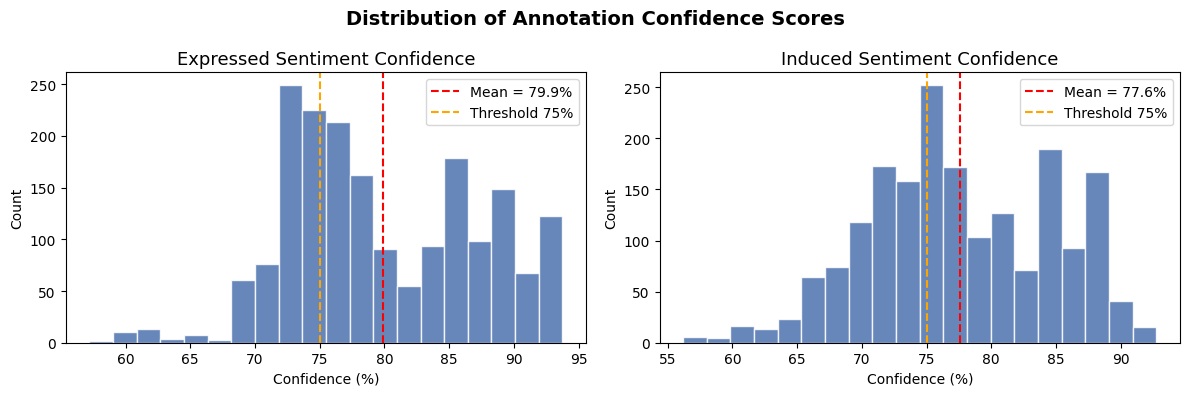

Saved: confidence_distribution.png ✓
Threshold ≥60%: expressed=1874 (99.6%), induced=1870 (99.4%)
Threshold ≥70%: expressed=1781 (94.7%), induced=1637 (87.0%)
Threshold ≥75%: expressed=1273 (67.7%), induced=1167 (62.0%)
Threshold ≥80%: expressed=827 (44.0%), induced=704 (37.4%)
Threshold ≥90%: expressed=257 (13.7%), induced=52 (2.8%)


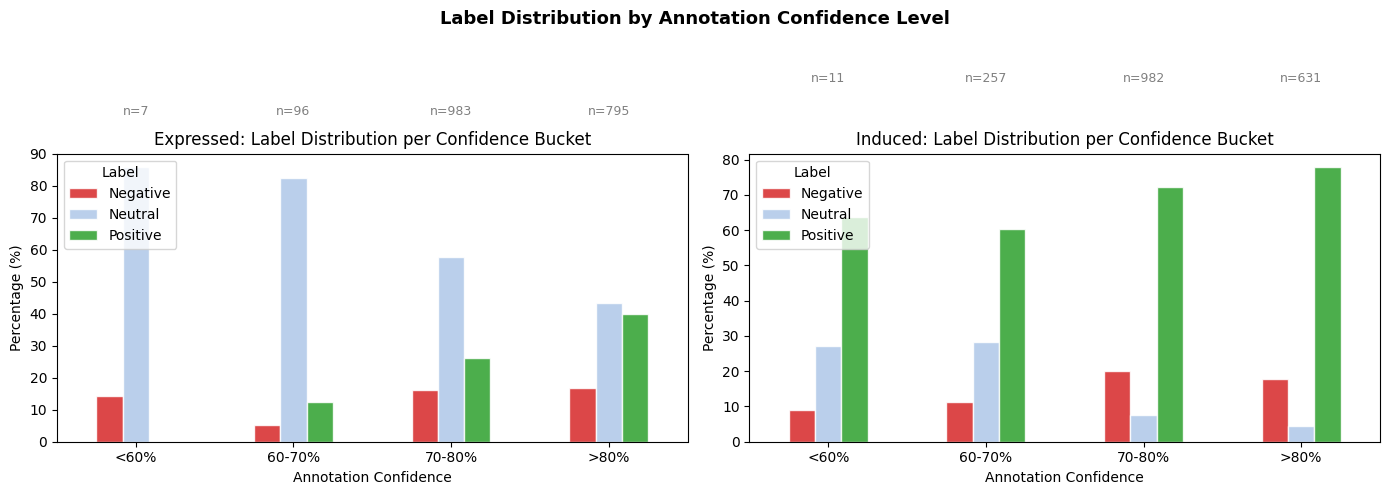

Saved: confidence_label_distribution.png ✓

Stήλες bert_results.csv: ['experiment', 'model', 'text', 'task', 'accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']

ΤΕΛΙΚΟΣ ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ — BEST RESULTS PER METHOD
                            Method      Task  F1_macro  F1_negative  F1_neutral  F1_positive
                  BERT Fine-tuning expressed    0.5124       0.4643      0.5703       0.5026
     Multimodal v1 (Claude Vision) expressed    0.3533       0.4615      0.0723       0.5260
Multimodal v2 (Unified+Stratified) expressed    0.3411       0.3429      0.1596       0.5210
            LLM Claude (text-only) expressed    0.3277       0.3188      0.1838       0.4805
Multimodal v2 (Unified+Stratified)   induced    0.5935       0.5625      0.3404       0.8775
     Multimodal v1 (Claude Vision)   induced    0.5673       0.5682      0.2500       0.8836
                  BERT Fine-tuning   induced    0.5664       0.5155      0.3188       0.8650
            LLM Claude (te

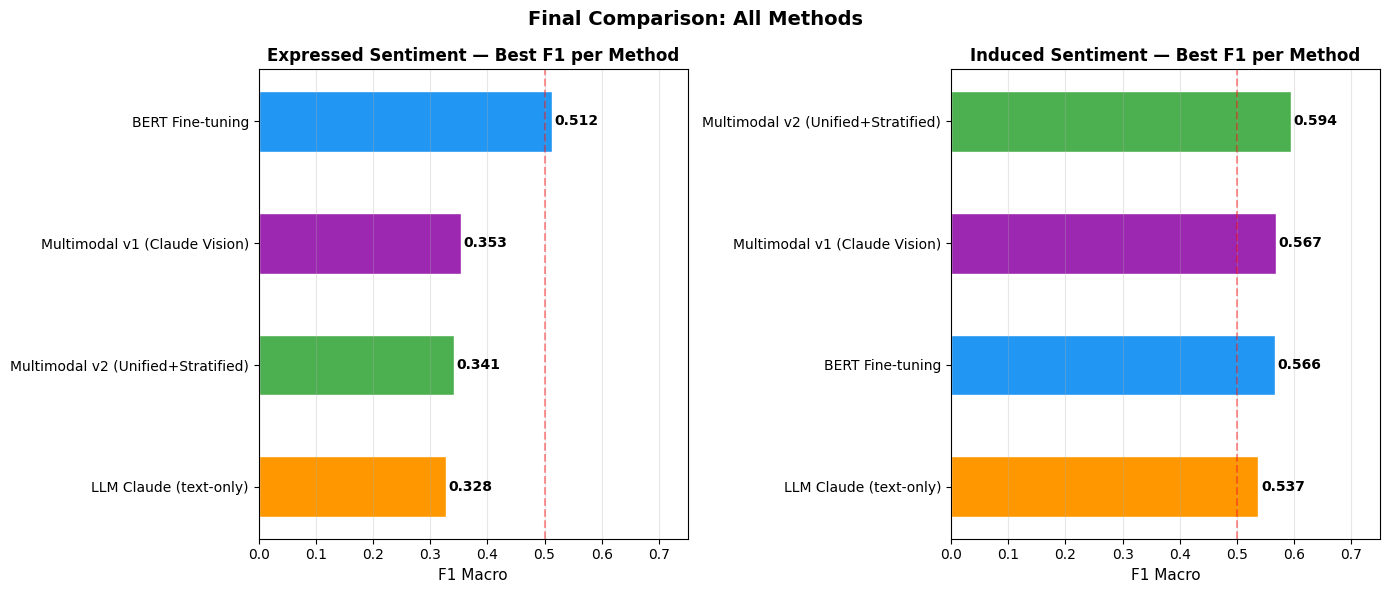

Saved: final_comparison_chart.png ✓

EXPRESSED vs INDUCED — AGREEMENT ANALYSIS
Agree    (expressed == induced): 929  (49.4%)
Disagree (expressed != induced): 952 (50.6%)

Συχνότητα κάθε combination (expressed / induced):
  ✗ Neutral / Positive            :  786 (41.8%)
  ✓ Positive / Positive           :  556 (29.6%)
  ✓ Negative / Negative           :  251 (13.3%)
  ✓ Neutral / Neutral             :  122 (6.5%)
  ✗ Neutral / Negative            :   89 (4.7%)
  ✗ Positive / Neutral            :   29 (1.5%)
  ✗ Negative / Neutral            :   28 (1.5%)
  ✗ Negative / Positive           :   20 (1.1%)


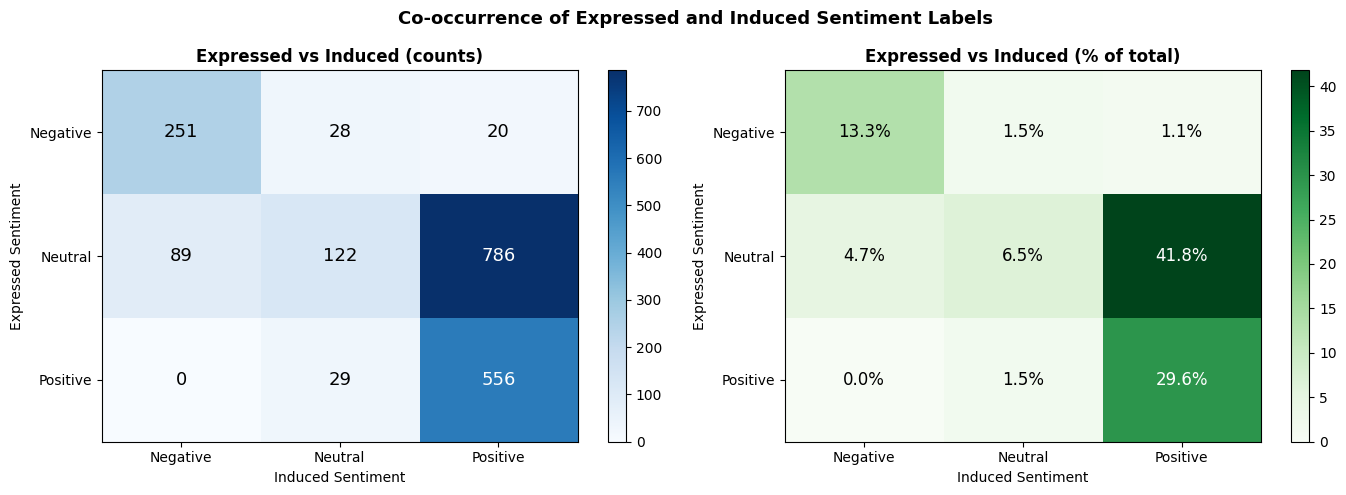

Saved: expressed_induced_heatmap.png ✓


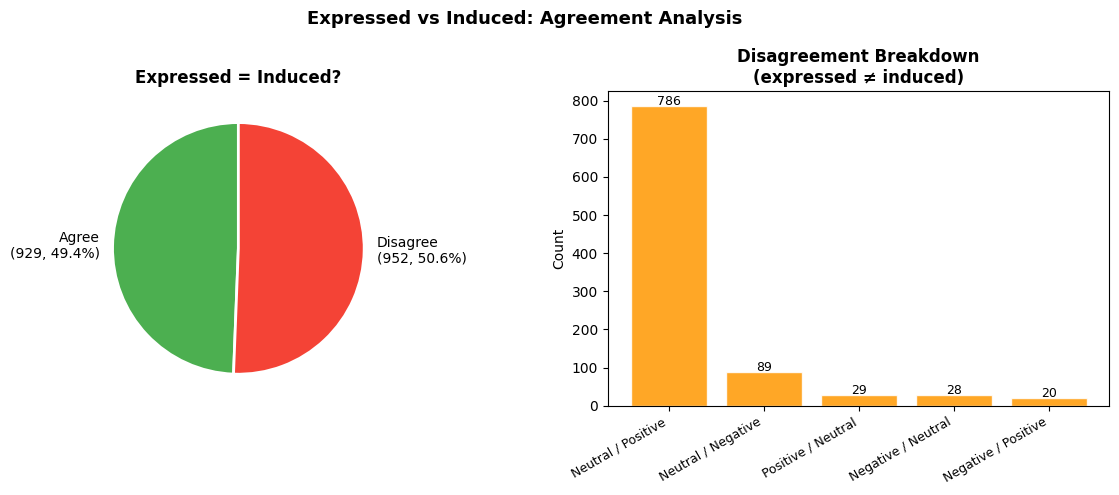

Saved: agreement_analysis.png ✓

--- Annotation Confidence: Agree vs Disagree samples ---

Agree samples (n=929):
  Expressed conf: mean=82.5%, median=80.8%
  Induced conf:   mean=79.4%, median=78.8%

Disagree samples (n=952):
  Expressed conf: mean=77.3%, median=75.0%
  Induced conf:   mean=75.8%, median=74.6%


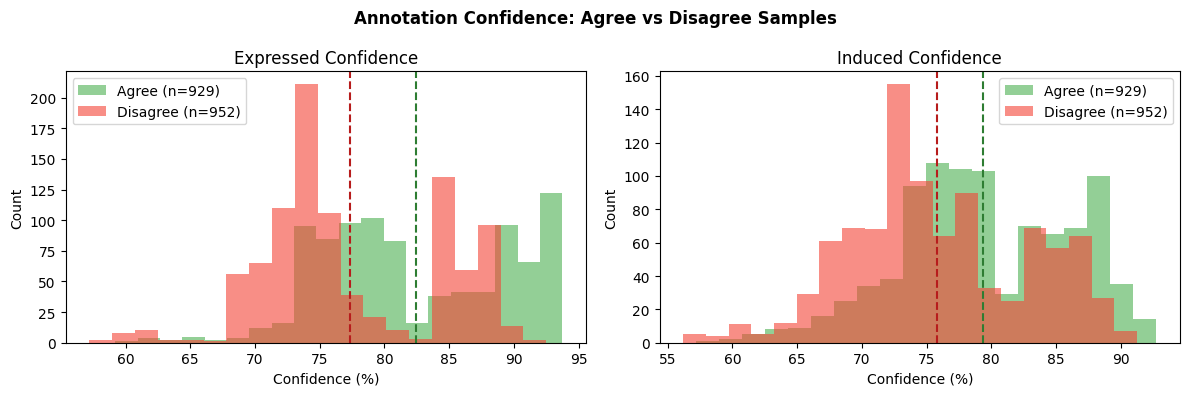

Saved: confidence_agree_disagree.png ✓

ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ!
Files που δημιουργήθηκαν:
  confidence_distribution.png
  confidence_label_distribution.png
  final_comparison.csv
  final_comparison_chart.png
  expressed_induced_heatmap.png
  agreement_analysis.png
  confidence_agree_disagree.png


In [17]:
# ============================================================
# ΑΝΑΛΥΣΗ  — CONFIDENCE ANALYSIS
# Ερώτηση: Αν κρατήσουμε μόνο τα high-confidence labels
# από το dataset, ανεβαίνει το F1 των μοντέλων μας;
#
# Λογική: Τα labels του dataset έχουν βγει από voting
# annotators. Samples με voted_expressed_conf > 75% σημαίνει
# ότι οι annotators συμφωνούσαν περισσότερο — άρα είναι
# "πιο σίγουρα" ground truth labels. Αν το μοντέλο τα
# πηγαίνει καλύτερα σε αυτά, επιβεβαιώνει ότι λειτουργεί σωστά.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# --- Φόρτωση ---
df_labels   = pd.read_csv("filtered_dataset_clean.csv")
multi_df    = pd.read_csv("multimodal_results.csv")
all_df      = pd.read_csv("all_results.csv")
bert_df     = pd.read_csv("bert_results.csv")

print("Φορτώθηκαν όλα τα CSVs ✓")
print(f"Dataset: {len(df_labels)} samples")
print(f"Confidence stats - Expressed: mean={df_labels['voted_expressed_conf'].mean():.1f}, "
      f"Induced: mean={df_labels['voted_induced_conf'].mean():.1f}")


# ============================================================
# ΚΕΛΙ 2Α — Κατανομή confidence scores
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], "voted_expressed_conf", "Expressed Sentiment Confidence"),
    (axes[1], "voted_induced_conf",   "Induced Sentiment Confidence")
]:
    ax.hist(df_labels[col], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(df_labels[col].mean(), color="red", linestyle="--",
               label=f"Mean = {df_labels[col].mean():.1f}%")
    ax.axvline(75, color="orange", linestyle="--", label="Threshold 75%")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Confidence (%)")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Distribution of Annotation Confidence Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confidence_distribution.png ✓")

# Στατιστικά για τα threshold levels
for thresh in [60, 70, 75, 80, 90]:
    n_exp = (df_labels["voted_expressed_conf"] >= thresh).sum()
    n_ind = (df_labels["voted_induced_conf"]   >= thresh).sum()
    print(f"Threshold ≥{thresh}%: expressed={n_exp} ({n_exp/len(df_labels)*100:.1f}%), "
          f"induced={n_ind} ({n_ind/len(df_labels)*100:.1f}%)")


# ============================================================
# ΚΕΛΙ 2Β — Σύγκριση: πώς επηρεάζει το confidence threshold
#            τα F1 scores των καλύτερων experiments
#
# Σημείωση: Εδώ δουλεύουμε με τα aggregated αποτελέσματα
# ανά confidence bucket του dataset — δείχνουμε ΠΟΣΑ samples
# είναι "εύκολα" (high confidence) vs "δύσκολα" (low confidence)
# και πώς κατανέμονται τα labels σε κάθε bucket.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, conf_col, label_col, title in [
    (axes[0], "voted_expressed_conf", "voted_expressed", "Expressed"),
    (axes[1], "voted_induced_conf",   "voted_induced",   "Induced")
]:
    # Bucketing σε 4 ζώνες
    bins   = [0, 60, 70, 80, 100]
    labels = ["<60%", "60-70%", "70-80%", ">80%"]
    df_labels["conf_bucket"] = pd.cut(
        df_labels[conf_col], bins=bins, labels=labels, right=True
    )

    # Κατανομή labels ανά bucket
    pivot = df_labels.groupby(
        ["conf_bucket", label_col], observed=True
    ).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    pivot_pct.plot(
        kind="bar", ax=ax, color=["#d62728","#aec7e8","#2ca02c"],
        edgecolor="white", alpha=0.85
    )
    ax.set_title(f"{title}: Label Distribution per Confidence Bucket", fontsize=12)
    ax.set_xlabel("Annotation Confidence")
    ax.set_ylabel("Percentage (%)")
    ax.set_xticklabels(labels, rotation=0)
    ax.legend(title="Label", loc="upper left")

    # Annotate με counts
    totals = df_labels["conf_bucket"].value_counts().sort_index()
    for i, (bucket, count) in enumerate(totals.items()):
        ax.text(i, 102, f"n={count}", ha="center", fontsize=9, color="gray")

plt.suptitle("Label Distribution by Annotation Confidence Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confidence_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confidence_label_distribution.png ✓")


# ============================================================
# ΚΕΛΙ 3 — ΤΕΛΙΚΟΣ ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ ΟΛΩΝ ΤΩΝ ΜΕΘΟΔΩΝ
# ============================================================

# --- Μαζεύουμε τα best results από κάθε method ---

rows = []

# 1. BERT (από bert_results.csv)
print("\nStήλες bert_results.csv:", bert_df.columns.tolist())

# Best BERT per task
for task in ["expressed", "induced"]:
    task_df = bert_df[bert_df["task"] == task] if "task" in bert_df.columns else bert_df
    # Αν έχει task column
    if "task" in bert_df.columns:
        best = bert_df[bert_df["task"] == task].sort_values("f1_macro", ascending=False).iloc[0]
        rows.append({
            "Method": "BERT Fine-tuning",
            "Task": task,
            "Best Experiment": best.get("experiment", best.get("model", "BERT")),
            "F1_macro": best["f1_macro"],
            "F1_negative": best.get("f1_negative", "-"),
            "F1_neutral":  best.get("f1_neutral",  "-"),
            "F1_positive": best.get("f1_positive", "-"),
        })

# 2. LLM text-only Claude (από all_results.csv)
if "method" in all_df.columns:
    claude_df = all_df[all_df["method"] == "LLM_Claude"]
else:
    claude_df = all_df

for task in ["expressed", "induced"]:
    subset = claude_df[claude_df["task"] == task]
    if len(subset) > 0:
        best = subset.sort_values("f1_macro", ascending=False).iloc[0]
        rows.append({
            "Method": "LLM Claude (text-only)",
            "Task": task,
            "Best Experiment": best.get("experiment", "claude"),
            "F1_macro": best["f1_macro"],
            "F1_negative": best.get("f1_negative", "-"),
            "F1_neutral":  best.get("f1_neutral",  "-"),
            "F1_positive": best.get("f1_positive", "-"),
        })

# 3. Multimodal v1 (από multimodal_results.csv — μόνο v1)
v1_df = multi_df[~multi_df["experiment"].str.contains("v2")]
for task in ["expressed", "induced"]:
    subset = v1_df[v1_df["task"] == task]
    if len(subset) > 0:
        best = subset.sort_values("f1_macro", ascending=False).iloc[0]
        rows.append({
            "Method": "Multimodal v1 (Claude Vision)",
            "Task": task,
            "Best Experiment": best["experiment"],
            "F1_macro": best["f1_macro"],
            "F1_negative": best.get("f1_negative", "-"),
            "F1_neutral":  best.get("f1_neutral",  "-"),
            "F1_positive": best.get("f1_positive", "-"),
        })

# 4. Multimodal v2 (από multimodal_results.csv — μόνο v2)
v2_df = multi_df[multi_df["experiment"].str.contains("v2")]
for task in ["expressed", "induced"]:
    subset = v2_df[v2_df["task"] == task]
    if len(subset) > 0:
        best = subset.sort_values("f1_macro", ascending=False).iloc[0]
        rows.append({
            "Method": "Multimodal v2 (Unified+Stratified)",
            "Task": task,
            "Best Experiment": best["experiment"],
            "F1_macro": best["f1_macro"],
            "F1_negative": best.get("f1_negative", "-"),
            "F1_neutral":  best.get("f1_neutral",  "-"),
            "F1_positive": best.get("f1_positive", "-"),
        })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values(["Task", "F1_macro"], ascending=[True, False])

print("\n" + "="*80)
print("ΤΕΛΙΚΟΣ ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ — BEST RESULTS PER METHOD")
print("="*80)
print(summary_df[["Method","Task","F1_macro","F1_negative","F1_neutral","F1_positive"]].to_string(index=False))

summary_df.to_csv("final_comparison.csv", index=False)
print("\nSaved: final_comparison.csv ✓")


# ============================================================
# ΚΕΛΙ 3Β — Οπτικοποίηση τελικής σύγκρισης
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {
    "BERT Fine-tuning":                  "#2196F3",
    "LLM Claude (text-only)":            "#FF9800",
    "Multimodal v1 (Claude Vision)":     "#9C27B0",
    "Multimodal v2 (Unified+Stratified)":"#4CAF50",
}

for ax, task in zip(axes, ["expressed", "induced"]):
    task_df = summary_df[summary_df["Task"] == task].copy()
    task_df = task_df.sort_values("F1_macro")

    bar_colors = [colors.get(m, "gray") for m in task_df["Method"]]
    bars = ax.barh(task_df["Method"], task_df["F1_macro"],
                   color=bar_colors, edgecolor="white", height=0.5)

    # Value labels
    for bar, val in zip(bars, task_df["F1_macro"]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10, fontweight="bold")

    ax.set_xlim(0, 0.75)
    ax.set_xlabel("F1 Macro", fontsize=11)
    ax.set_title(f"{task.capitalize()} Sentiment — Best F1 per Method", fontsize=12, fontweight="bold")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.4, label="F1=0.5")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Final Comparison: All Methods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("final_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_comparison_chart.png ✓")


# ============================================================
# ΚΕΛΙ 5 — EXPRESSED/INDUCED AGREEMENT ANALYSIS
#
# Ερώτηση: Σε πόσα samples διαφέρουν τα δύο labels;
# Πώς κατανέμονται τα "διαφωνίες"; Ποια combination είναι
# πιο συχνή; Αυτό είναι το ΚΕΝΤΡΙΚΟ ερώτημα της διπλωματικής.
# ============================================================

# --- 5Α: Συχνότητα agreement/disagreement στο dataset ---
df_labels["agree"] = (
    df_labels["voted_expressed"].str.lower() ==
    df_labels["voted_induced"].str.lower()
)

agree_count    = df_labels["agree"].sum()
disagree_count = (~df_labels["agree"]).sum()
total          = len(df_labels)

print("\n" + "="*60)
print("EXPRESSED vs INDUCED — AGREEMENT ANALYSIS")
print("="*60)
print(f"Agree    (expressed == induced): {agree_count}  ({agree_count/total*100:.1f}%)")
print(f"Disagree (expressed != induced): {disagree_count} ({disagree_count/total*100:.1f}%)")

# --- 5Β: Κατανομή όλων των combinations ---
df_labels["combination"] = (
    df_labels["voted_expressed"].str.capitalize() + " / " +
    df_labels["voted_induced"].str.capitalize()
)

combo_counts = df_labels["combination"].value_counts()
print("\nΣυχνότητα κάθε combination (expressed / induced):")
for combo, count in combo_counts.items():
    pct   = count / total * 100
    match = "✓" if combo.split(" / ")[0] == combo.split(" / ")[1] else "✗"
    print(f"  {match} {combo:30s}: {count:4d} ({pct:.1f}%)")

# --- 5Γ: Heatmap combinations ---
labels_order = ["Negative", "Neutral", "Positive"]
matrix = pd.crosstab(
    df_labels["voted_expressed"].str.capitalize(),
    df_labels["voted_induced"].str.capitalize()
).reindex(index=labels_order, columns=labels_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
import matplotlib.colors as mcolors
im1 = axes[0].imshow(matrix.values, cmap="Blues", aspect="auto")
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(labels_order); axes[0].set_yticklabels(labels_order)
axes[0].set_xlabel("Induced Sentiment"); axes[0].set_ylabel("Expressed Sentiment")
axes[0].set_title("Expressed vs Induced (counts)", fontweight="bold")
plt.colorbar(im1, ax=axes[0])
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(matrix.values[i,j]),
                     ha="center", va="center", fontsize=13,
                     color="white" if matrix.values[i,j] > matrix.values.max()*0.6 else "black")

# Percentages
matrix_pct = matrix.div(matrix.sum().sum()) * 100
im2 = axes[1].imshow(matrix_pct.values, cmap="Greens", aspect="auto")
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(labels_order); axes[1].set_yticklabels(labels_order)
axes[1].set_xlabel("Induced Sentiment"); axes[1].set_ylabel("Expressed Sentiment")
axes[1].set_title("Expressed vs Induced (% of total)", fontweight="bold")
plt.colorbar(im2, ax=axes[1])
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{matrix_pct.values[i,j]:.1f}%",
                     ha="center", va="center", fontsize=12,
                     color="white" if matrix_pct.values[i,j] > matrix_pct.values.max()*0.6 else "black")

plt.suptitle("Co-occurrence of Expressed and Induced Sentiment Labels",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("expressed_induced_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: expressed_induced_heatmap.png ✓")


# --- 5Δ: Pie chart agree vs disagree ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Agree/disagree pie
axes[0].pie(
    [agree_count, disagree_count],
    labels=[f"Agree\n({agree_count}, {agree_count/total*100:.1f}%)",
            f"Disagree\n({disagree_count}, {disagree_count/total*100:.1f}%)"],
    colors=["#4CAF50", "#F44336"],
    startangle=90, autopct=None,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Expressed = Induced?", fontsize=12, fontweight="bold")

# Breakdown των disagree combinations
disagree_df   = df_labels[~df_labels["agree"]]
disagree_combo = disagree_df["combination"].value_counts()
axes[1].bar(range(len(disagree_combo)), disagree_combo.values,
            color="#FF9800", edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(disagree_combo)))
axes[1].set_xticklabels(disagree_combo.index, rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Count")
axes[1].set_title("Disagreement Breakdown\n(expressed ≠ induced)", fontsize=12, fontweight="bold")
for i, v in enumerate(disagree_combo.values):
    axes[1].text(i, v + 2, str(v), ha="center", fontsize=9)

plt.suptitle("Expressed vs Induced: Agreement Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("agreement_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: agreement_analysis.png ✓")


# --- 5Ε: Δυσκολία classification ανά combination ---
# Θεωρία: τα "disagree" samples είναι πιο δύσκολα για τα μοντέλα
# Δείχνουμε το confidence των annotators για agree vs disagree

print("\n--- Annotation Confidence: Agree vs Disagree samples ---")
for group, label in [(df_labels[df_labels["agree"]], "Agree"),
                     (df_labels[~df_labels["agree"]], "Disagree")]:
    print(f"\n{label} samples (n={len(group)}):")
    print(f"  Expressed conf: mean={group['voted_expressed_conf'].mean():.1f}%, "
          f"median={group['voted_expressed_conf'].median():.1f}%")
    print(f"  Induced conf:   mean={group['voted_induced_conf'].mean():.1f}%, "
          f"median={group['voted_induced_conf'].median():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], "voted_expressed_conf", "Expressed Confidence"),
    (axes[1], "voted_induced_conf",   "Induced Confidence")
]:
    agree_vals    = df_labels[df_labels["agree"]][col]
    disagree_vals = df_labels[~df_labels["agree"]][col]
    ax.hist(agree_vals,    bins=20, alpha=0.6, color="#4CAF50", label=f"Agree (n={len(agree_vals)})")
    ax.hist(disagree_vals, bins=20, alpha=0.6, color="#F44336", label=f"Disagree (n={len(disagree_vals)})")
    ax.axvline(agree_vals.mean(),    color="#2e7d32", linestyle="--", linewidth=1.5)
    ax.axvline(disagree_vals.mean(), color="#b71c1c", linestyle="--", linewidth=1.5)
    ax.set_title(title); ax.set_xlabel("Confidence (%)"); ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Annotation Confidence: Agree vs Disagree Samples",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confidence_agree_disagree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confidence_agree_disagree.png ✓")

print("\n" + "="*60)
print("ΑΝΑΛΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ!")
print("Files που δημιουργήθηκαν:")
print("  confidence_distribution.png")
print("  confidence_label_distribution.png")
print("  final_comparison.csv")
print("  final_comparison_chart.png")
print("  expressed_induced_heatmap.png")
print("  agreement_analysis.png")
print("  confidence_agree_disagree.png")

In [18]:
# ============================================================
# EXPERIMENTS #1, #2, #3, #5
#
# #1 — Claude Sonnet vs Haiku (best scenario: v2_media)
# #2 — Confidence scoring (expressed_conf + induced_conf)
# #3 — Text-only ablation (v2 prompt χωρίς εικόνα)
# #5 — Disagree samples analysis (expressed ≠ induced)
#
# ΠΡΟΑΠΑΙΤΟΥΜΕΝΑ: τρέξε πρώτα τα κελιά 1-6 του v2 κώδικα
# ώστε να είναι φορτωμένα: client, DEFS_*, FEW_SHOTS_V2,
# build_unified_prompt_v2, load_image_base64, find_image_path
# ============================================================
 
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, time, os
from tqdm import tqdm
from sklearn.metrics import classification_report
from dotenv import load_dotenv
import anthropic
 
load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
 
df_labels = pd.read_csv("filtered_dataset_clean.csv")
multi_df  = pd.read_csv("multimodal_results.csv")
IMAGE_DIR = "matched_images/matched_images"
 
print("Setup complete ✓")
 

Setup complete ✓


In [19]:
# ============================================================
# ΚΕΛΙ #2 — CONFIDENCE SCORING
# Τροποποιούμε το prompt και τη classify function ώστε
# το μοντέλο να επιστρέφει και confidence για κάθε label.
# ============================================================
 
def build_unified_prompt_v2_conf(text, defs, few_shots):
    """
    Ίδιο με το v2 αλλά ζητάει και confidence scores.
    """
    examples_text = ""
    for i, ex in enumerate(few_shots, 1):
        examples_text += f"""
Example {i}:
Image shows: {ex['image_desc']}
Text: "{ex['text']}"
Step 1 - What does the image show: {ex['image_desc']}
Step 2 - What is the author saying: {ex['text'][:80]}
Step 3 - Does the image reinforce, contradict, or add context to the text: {"Reinforces" if ex["expressed"] == ex["induced"] else "Adds contrasting context"}
Step 4 - What emotion does the AUTHOR express (expressed): {ex['expressed']}
Step 5 - How would the AUDIENCE react seeing image + text together (induced): {ex['induced']}
Reasoning: {ex['reasoning']}
{{"expressed": "{ex['expressed']}", "expressed_conf": 90, "induced": "{ex['induced']}", "induced_conf": 85}}
"""
 
    prompt = f"""You are an expert sentiment analyst specializing in social media content.
 
TASK: Given a social media post (image + text), classify TWO sentiments AND provide confidence scores:
1. EXPRESSED sentiment = what emotion the AUTHOR explicitly shows
2. INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel
 
IMPORTANT: These two can be DIFFERENT. For example:
- A brand posting enthusiastically (expressed=Positive) may only inform readers (induced=Neutral)
- A neutral news report (expressed=Neutral) may upset readers (induced=Negative)
 
Sentiment Definitions:
- Positive: {defs['positive']}
- Neutral:  {defs['neutral']}
- Negative: {defs['negative']}
 
Here are examples:
{examples_text}
 
Now classify THIS post. Use BOTH the image AND the text.
Text: "{text}"
 
Think step by step:
Step 1 - What does the image show:
Step 2 - What is the author saying in the text:
Step 3 - Does the image REINFORCE, CONTRADICT, or ADD CONTEXT to the text:
Step 4 - What emotion does the AUTHOR express (expressed sentiment):
Step 5 - How would the AUDIENCE react seeing image + text together (induced sentiment):
Step 6 - How confident are you for each prediction (0-100)?
 
Return ONLY this JSON at the end:
{{"expressed": "Positive/Neutral/Negative", "expressed_conf": 0-100, "induced": "Positive/Neutral/Negative", "induced_conf": 0-100}}"""
 
    return prompt
 
 
def classify_multimodal_v2_conf(text, image_path, defs, few_shots, model="claude-haiku-4-5-20251001"):
    """
    v2 με confidence scores. Δουλεύει και για Haiku και για Sonnet.
    """
    img_b64, media_type = load_image_base64(image_path)
    if img_b64 is None:
        return {"expressed": "Error", "expressed_conf": 0,
                "induced": "Error",   "induced_conf": 0}
 
    prompt = build_unified_prompt_v2_conf(text, defs, few_shots)
 
    try:
        response = client.messages.create(
            model=model,
            max_tokens=600,
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_b64
                        }
                    },
                    {"type": "text", "text": prompt}
                ]
            }]
        )
        raw      = response.content[0].text
        json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
        parsed   = json.loads(json_str)
 
        valid = {"Positive", "Neutral", "Negative"}
        expressed      = parsed.get("expressed",      "Error").capitalize()
        induced        = parsed.get("induced",        "Error").capitalize()
        expressed_conf = parsed.get("expressed_conf", 0)
        induced_conf   = parsed.get("induced_conf",   0)
 
        if expressed not in valid: expressed = "Error"
        if induced   not in valid: induced   = "Error"
 
        return {
            "expressed":      expressed,
            "expressed_conf": expressed_conf,
            "induced":        induced,
            "induced_conf":   induced_conf
        }
 
    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "expressed_conf": 0,
                "induced": "Error",   "induced_conf": 0}
 
 
print("Confidence classify function ready ✓")
 
 

Confidence classify function ready ✓


In [20]:
# ============================================================
# ΚΕΛΙ #1 + #2 RUNNER
# Τρέχει και Haiku και Sonnet με confidence scoring
# Σενάριο: v2_media (το καλύτερο)
# ============================================================
 
def run_conf_experiment(model, exp_name, defs, few_shots,
                        image_dir="matched_images/matched_images"):
    print("\n" + "="*60)
    print(f"Experiment: {exp_name}  |  Model: {model}")
    print("="*60)
 
    subset = test_df[test_df["fname"].notna()].copy()
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, image_dir)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples με εικόνα: {len(subset)}")
 
    expressed_preds, induced_preds = [], []
    expressed_confs, induced_confs = [], []
 
    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal_v2_conf(
            row["text_norm_clean"], row["image_path"], defs, few_shots, model=model
        )
        expressed_preds.append(result["expressed"])
        induced_preds.append(result["induced"])
        expressed_confs.append(result["expressed_conf"])
        induced_confs.append(result["induced_conf"])
 
    subset["pred_expressed"]      = expressed_preds
    subset["pred_induced"]        = induced_preds
    subset["conf_expressed"]      = expressed_confs
    subset["conf_induced"]        = induced_confs
 
    results = {}
    for task, pred_col, true_col, conf_col in [
        ("expressed", "pred_expressed", "voted_expressed", "conf_expressed"),
        ("induced",   "pred_induced",   "voted_induced",   "conf_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
 
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True, zero_division=0
        )
 
        results[task] = {
            "experiment":  exp_name,
            "model":       model,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
            "mean_conf":   round(subset.loc[mask, conf_col].mean(), 1),
        }
 
        print(f"\n{task.upper()}:")
        print(f"  Errors: {results[task]['n_errors']}")
        print(f"  Acc={results[task]['accuracy']} | F1_macro={results[task]['f1_macro']}")
        print(f"  Neg={results[task]['f1_negative']} | Neu={results[task]['f1_neutral']} | Pos={results[task]['f1_positive']}")
        print(f"  Mean model confidence: {results[task]['mean_conf']}%")
 
    return results, subset
 
 
# --- Test σε 3 samples πρώτα ---
print("Test confidence scoring σε 3 samples...\n")
test_subset = test_df[test_df["fname"].notna()].head(3).copy()
for _, row in test_subset.iterrows():
    img_path = find_image_path(row["fname"], IMAGE_DIR)
    if img_path is None: continue
    result = classify_multimodal_v2_conf(
        row["text_norm_clean"], img_path, DEFS_MEDIA, FEW_SHOTS_V2
    )
    print(f"Text: {row['text_norm_clean'][:55]}...")
    print(f"  expressed={result['expressed']} (conf={result['expressed_conf']}%)")
    print(f"  induced={result['induced']} (conf={result['induced_conf']}%)")
    print()
    time.sleep(0.5)
 

Test confidence scoring σε 3 samples...

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην An...
  expressed=Positive (conf=90%)
  induced=Positive (conf=85%)

Text: Η επιχείρησή σου αξίζει την καλύτερη προστασία. Στην An...
  expressed=Positive (conf=85%)
  induced=Positive (conf=80%)

Text: Премиера на “Хадерал – последното пътуване на Константи...
  expressed=Positive (conf=88%)
  induced=Positive (conf=82%)



In [22]:
# ============================================================
# ΚΕΛΙ — SONNET ONLY (media defs)
# Haiku: χρησιμοποιούμε παλιά αποτελέσματα από v2_media
# ============================================================

conf_results = []

# #1 — Sonnet με confidence (media defs)
r_sonnet, subset_sonnet = run_conf_experiment(
    model    = "claude-sonnet-4-6",
    exp_name = "multimodal_v2_conf_sonnet_media",
    defs     = DEFS_MEDIA,
    few_shots= FEW_SHOTS_V2
)
for task, res in r_sonnet.items():
    conf_results.append(res)

conf_df = pd.DataFrame(conf_results)
conf_df.to_csv("conf_results.csv", index=False)
print("\nSaved: conf_results.csv ✓")
print(conf_df[["experiment","task","f1_macro","mean_conf"]].to_string(index=False))


Experiment: multimodal_v2_conf_sonnet_media  |  Model: claude-sonnet-4-6
Samples με εικόνα: 296


100%|██████████| 296/296 [50:46<00:00, 10.29s/it]



EXPRESSED:
  Errors: 0
  Acc=0.4054 | F1_macro=0.3455
  Neg=0.2903 | Neu=0.2094 | Pos=0.5369
  Mean model confidence: 88.6%

INDUCED:
  Errors: 0
  Acc=0.723 | F1_macro=0.562
  Neg=0.5682 | Neu=0.2821 | Pos=0.8357
  Mean model confidence: 82.9%

Saved: conf_results.csv ✓
                     experiment      task  f1_macro  mean_conf
multimodal_v2_conf_sonnet_media expressed    0.3455       88.6
multimodal_v2_conf_sonnet_media   induced    0.5620       82.9



=== CONFIDENCE THRESHOLD ANALYSIS ===


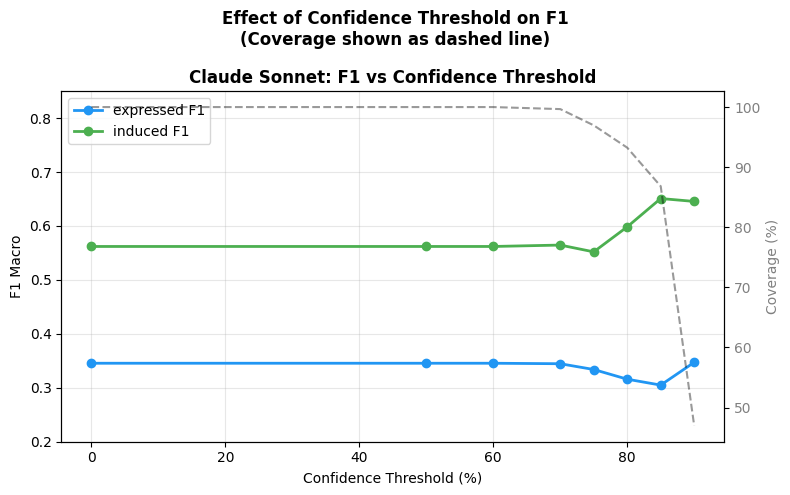

Saved: confidence_threshold_analysis.png ✓


In [24]:
# ============================================================
# ΚΕΛΙ — CONFIDENCE THRESHOLD ANALYSIS (#2)
# Μόνο Sonnet (το Haiku δεν έχει per-sample predictions)
# ============================================================

print("\n=== CONFIDENCE THRESHOLD ANALYSIS ===")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

thresholds = [0, 50, 60, 70, 75, 80, 85, 90]
results_thresh = {"expressed": [], "induced": []}

for thresh in thresholds:
    for task, pred_col, true_col, conf_col in [
        ("expressed", "pred_expressed", "voted_expressed", "conf_expressed"),
        ("induced",   "pred_induced",   "voted_induced",   "conf_induced")
    ]:
        mask = (subset_sonnet[pred_col] != "Error") & (subset_sonnet[conf_col] >= thresh)
        if mask.sum() < 10:
            results_thresh[task].append(None)
            continue
        y_true = subset_sonnet.loc[mask, true_col].str.capitalize()
        y_pred = subset_sonnet.loc[mask, pred_col]
        report = classification_report(
            y_true, y_pred,
            labels=["Negative","Neutral","Positive"],
            output_dict=True, zero_division=0
        )
        results_thresh[task].append(round(report["macro avg"]["f1-score"], 4))

# Coverage
coverages = []
for thresh in thresholds:
    n = int(((subset_sonnet["conf_expressed"] >= thresh) & (subset_sonnet["pred_expressed"] != "Error")).sum())
    coverages.append(n / len(subset_sonnet) * 100)

ax2 = ax.twinx()
ax2.plot(thresholds, coverages, "k--", alpha=0.4, linewidth=1.5, label="Coverage %")
ax2.set_ylabel("Coverage (%)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

for task, color in [("expressed", "#2196F3"), ("induced", "#4CAF50")]:
    vals = results_thresh[task]
    valid = [(t, v) for t, v in zip(thresholds, vals) if v is not None]
    if valid:
        ts, vs = zip(*valid)
        ax.plot(ts, vs, "o-", color=color, linewidth=2,
                markersize=6, label=f"{task} F1")

ax.set_xlabel("Confidence Threshold (%)")
ax.set_ylabel("F1 Macro")
ax.set_title("Claude Sonnet: F1 vs Confidence Threshold", fontsize=12, fontweight="bold")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_ylim(0.2, 0.85)

plt.suptitle("Effect of Confidence Threshold on F1\n(Coverage shown as dashed line)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confidence_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confidence_threshold_analysis.png ✓")

Induced (πράσινο): Με threshold ≥85% το F1 ανεβαίνει από 0.562 → 0.65+! Δηλαδή αν κρατάς μόνο τα high-confidence predictions του Sonnet, το induced γίνεται το καλύτερο αποτέλεσμα που έχεις δει ποτέ.
Expressed (μπλε): Παραμένει σταθερό μέχρι ~80%, μετά ανεβαίνει ελαφρά στο 90% — αλλά εκεί η coverage πέφτει πολύ (~55%).
Το πρακτικό συμπέρασμα: Το σύστημα μπορεί να λειτουργεί σε "selective mode" — να κάνει prediction μόνο όταν είναι σίγουρο (conf≥85%) και να αρνείται για τα υπόλοιπα. Αυτό έχει πραγματική αξία για ένα production σύστημα.

In [25]:
# ============================================================
# ΚΕΛΙ #3 — TEXT-ONLY ABLATION
# Ίδιο v2 prompt αλλά χωρίς εικόνα.
# Αποδεικνύει αν η εικόνα πραγματικά βοηθάει.
# ============================================================
 
def classify_textonly_v2(text, defs, few_shots, model="claude-haiku-4-5-20251001"):
    """
    Ίδιο prompt με το v2 αλλά χωρίς εικόνα — μόνο κείμενο.
    """
    # Φτιάχνουμε text-only version του prompt
    # (αφαιρούμε αναφορές σε εικόνα από τα steps)
    examples_text = ""
    for i, ex in enumerate(few_shots, 1):
        examples_text += f"""
Example {i}:
Text: "{ex['text']}"
Step 1 - What is the author saying: {ex['text'][:80]}
Step 2 - What emotion does the AUTHOR express (expressed): {ex['expressed']}
Step 3 - How would the AUDIENCE react reading this (induced): {ex['induced']}
Reasoning: {ex['reasoning']}
{{"expressed": "{ex['expressed']}", "induced": "{ex['induced']}"}}
"""
 
    prompt = f"""You are an expert sentiment analyst specializing in social media content.
 
TASK: Given a social media post text, classify TWO sentiments:
1. EXPRESSED sentiment = what emotion the AUTHOR explicitly shows
2. INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel
 
IMPORTANT: These two can be DIFFERENT.
 
Sentiment Definitions:
- Positive: {defs['positive']}
- Neutral:  {defs['neutral']}
- Negative: {defs['negative']}
 
Examples:
{examples_text}
 
Now classify THIS post (text only):
Text: "{text}"
 
Think step by step:
Step 1 - What is the author saying:
Step 2 - What emotion does the AUTHOR express (expressed sentiment):
Step 3 - How would the AUDIENCE react reading this (induced sentiment):
 
Return ONLY this JSON at the end:
{{"expressed": "Positive/Neutral/Negative", "induced": "Positive/Neutral/Negative"}}"""
 
    try:
        response = client.messages.create(
            model=model,
            max_tokens=500,
            messages=[{"role": "user", "content": prompt}]
        )
        raw      = response.content[0].text
        json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
        parsed   = json.loads(json_str)
 
        valid     = {"Positive", "Neutral", "Negative"}
        expressed = parsed.get("expressed", "Error").capitalize()
        induced   = parsed.get("induced",   "Error").capitalize()
        if expressed not in valid: expressed = "Error"
        if induced   not in valid: induced   = "Error"
        return {"expressed": expressed, "induced": induced}
 
    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "induced": "Error"}
 
 
def run_textonly_experiment(model, exp_name, defs, few_shots):
    print("\n" + "="*60)
    print(f"Experiment: {exp_name}  |  Model: {model}")
    print("="*60)
 
    # Χρησιμοποιούμε τα ίδια samples με το multimodal
    # (μόνο αυτά που είχαν εικόνα, για fair comparison)
    subset = test_df[test_df["fname"].notna()].copy()
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, IMAGE_DIR)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples (ίδια με multimodal): {len(subset)}")
 
    expressed_preds, induced_preds = [], []
 
    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_textonly_v2(
            row["text_norm_clean"], defs, few_shots, model=model
        )
        expressed_preds.append(result["expressed"])
        induced_preds.append(result["induced"])
 
    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds
 
    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
 
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True, zero_division=0
        )
 
        results[task] = {
            "experiment":  exp_name,
            "model":       model,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }
 
        print(f"\n{task.upper()}:")
        print(f"  Errors: {results[task]['n_errors']}")
        print(f"  Acc={results[task]['accuracy']} | F1_macro={results[task]['f1_macro']}")
        print(f"  Neg={results[task]['f1_negative']} | Neu={results[task]['f1_neutral']} | Pos={results[task]['f1_positive']}")
 
    return results, subset
 
 
# Τρέξε text-only με Haiku (media defs) — ~20 λεπτά
r_textonly, subset_textonly = run_textonly_experiment(
    model    = "claude-haiku-4-5-20251001",
    exp_name = "textonly_v2_haiku_media",
    defs     = DEFS_MEDIA,
    few_shots= FEW_SHOTS_V2
)
 
textonly_df = pd.DataFrame(r_textonly.values())
textonly_df.to_csv("textonly_results.csv", index=False)
print("\nSaved: textonly_results.csv ✓")


Experiment: textonly_v2_haiku_media  |  Model: claude-haiku-4-5-20251001
Samples (ίδια με multimodal): 296


 69%|██████▊   | 203/296 [11:26<02:46,  1.79s/it]

Error: Expecting value: line 1 column 1 (char 0)


 69%|██████▉   | 204/296 [11:27<02:38,  1.72s/it]

Error: Expecting value: line 1 column 1 (char 0)


...

Error: Expecting value: line 1 column 1 (char 0)


 88%|████████▊ | 260/296 [14:30<01:02,  1.75s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 296/296 [16:36<00:00,  3.37s/it]


EXPRESSED:
  Errors: 4
  Acc=0.3664 | F1_macro=0.3113
  Neg=0.2295 | Neu=0.2167 | Pos=0.4875

INDUCED:
  Errors: 4
  Acc=0.6918 | F1_macro=0.5054
  Neg=0.5055 | Neu=0.1918 | Pos=0.819

Saved: textonly_results.csv ✓


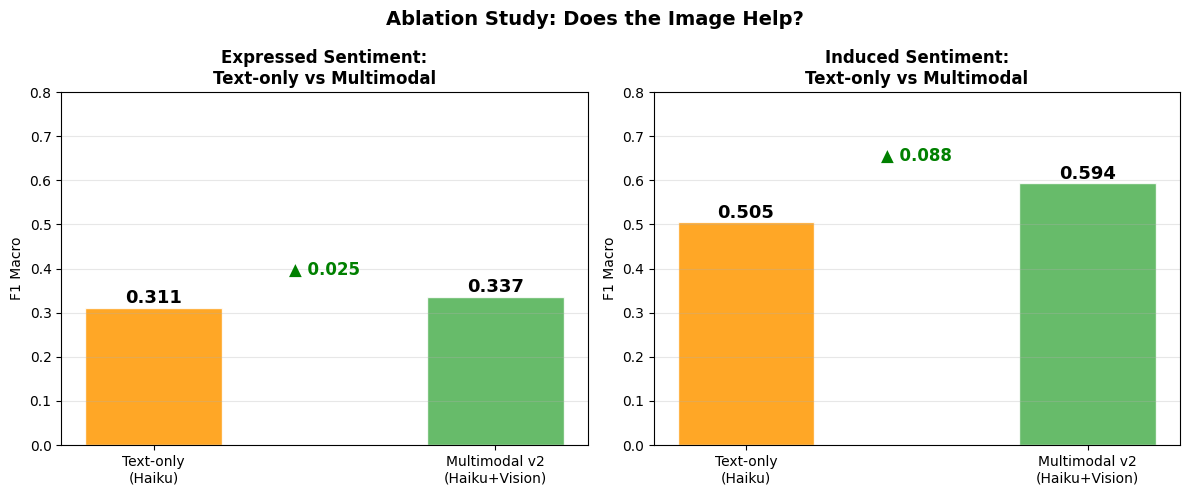

Saved: textonly_vs_multimodal.png ✓


In [26]:
# ============================================================
# ΚΕΛΙ — MULTIMODAL vs TEXT-ONLY COMPARISON CHART (#3)
# ============================================================
 
#  v2_media από multimodal_results
v2_media = multi_df[multi_df["experiment"] == "multimodal_unified_v2_media"]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, task in zip(axes, ["expressed", "induced"]):
    mm_row = v2_media[v2_media["task"] == task].iloc[0]
    to_row = textonly_df[textonly_df["task"] == task].iloc[0]
 
    methods = ["Text-only\n(Haiku)", "Multimodal v2\n(Haiku+Vision)"]
    f1s     = [to_row["f1_macro"], mm_row["f1_macro"]]
    colors  = ["#FF9800", "#4CAF50"]
 
    bars = ax.bar(methods, f1s, color=colors, edgecolor="white",
                  width=0.4, alpha=0.85)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=13, fontweight="bold")
 
    diff = mm_row["f1_macro"] - to_row["f1_macro"]
    arrow_color = "green" if diff > 0 else "red"
    ax.annotate(
        f"{'▲' if diff > 0 else '▼'} {abs(diff):.3f}",
        xy=(0.5, max(f1s) + 0.05), xycoords=("axes fraction", "data"),
        ha="center", fontsize=12, color=arrow_color, fontweight="bold"
    )
 
    ax.set_ylim(0, 0.8)
    ax.set_ylabel("F1 Macro")
    ax.set_title(f"{task.capitalize()} Sentiment:\nText-only vs Multimodal", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
 
plt.suptitle("Ablation Study: Does the Image Help?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("textonly_vs_multimodal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: textonly_vs_multimodal.png ✓")

In [27]:
# ============================================================
# ΚΕΛΙ #5 — DISAGREE SAMPLES ANALYSIS
#  v2 ΜΟΝΟ στα samples όπου expressed ≠ induced
# ============================================================
 
# Βρίσκουμε τα disagree samples από το test set
df_labels["agree"] = (
    df_labels["voted_expressed"].str.lower() ==
    df_labels["voted_induced"].str.lower()
)
 
# Merge με test_df για να πάρουμε τα disagree test samples
test_with_agree = test_df.copy()
test_with_agree = test_with_agree.merge(
    df_labels[["voted_expressed", "voted_induced", "voted_expressed_conf",
               "voted_induced_conf"]].assign(
        agree=df_labels["agree"]
    ).reset_index(drop=True),
    on=["voted_expressed", "voted_induced"],
    how="left",
    suffixes=("", "_dup")
)
 
# Εναλλακτικά: υπολόγισε agree απευθείας
test_df["agree"] = (
    test_df["voted_expressed"].str.lower() ==
    test_df["voted_induced"].str.lower()
)
 
disagree_test = test_df[
    (~test_df["agree"]) & (test_df["fname"].notna())
].copy()
disagree_test["image_path"] = disagree_test["fname"].apply(
    lambda x: find_image_path(x, IMAGE_DIR)
)
disagree_test = disagree_test[disagree_test["image_path"].notna()].copy()
 
agree_test = test_df[
    (test_df["agree"]) & (test_df["fname"].notna())
].copy()
agree_test["image_path"] = agree_test["fname"].apply(
    lambda x: find_image_path(x, IMAGE_DIR)
)
agree_test = agree_test[agree_test["image_path"].notna()].copy()
 
print(f"Test samples — Agree: {len(agree_test)}, Disagree: {len(disagree_test)}")
print(f"Disagree combinations:")
print(disagree_test.groupby(["voted_expressed","voted_induced"]).size().sort_values(ascending=False))
 
 
def run_subset_experiment(subset, exp_name, defs, few_shots,
                          model="claude-haiku-4-5-20251001"):
    print("\n" + "="*60)
    print(f"Experiment: {exp_name} | n={len(subset)}")
    print("="*60)
 
    expressed_preds, induced_preds = [], []
    expressed_confs, induced_confs = [], []
 
    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal_v2_conf(
            row["text_norm_clean"], row["image_path"], defs, few_shots, model=model
        )
        expressed_preds.append(result["expressed"])
        induced_preds.append(result["induced"])
        expressed_confs.append(result["expressed_conf"])
        induced_confs.append(result["induced_conf"])
 
    subset = subset.copy()
    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds
    subset["conf_expressed"] = expressed_confs
    subset["conf_induced"]   = induced_confs
 
    results = {}
    for task, pred_col, true_col, conf_col in [
        ("expressed", "pred_expressed", "voted_expressed", "conf_expressed"),
        ("induced",   "pred_induced",   "voted_induced",   "conf_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
 
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True, zero_division=0
        )
 
        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
            "mean_conf":   round(subset.loc[mask, conf_col].mean(), 1),
        }
 
        print(f"\n{task.upper()}: F1={results[task]['f1_macro']} | mean_conf={results[task]['mean_conf']}%")
 
    return results, subset
 
 
# Τρέξε agree vs disagree (media defs, Haiku)
r_agree,    subset_agree    = run_subset_experiment(
    agree_test,    "agree_samples",    DEFS_MEDIA, FEW_SHOTS_V2
)
r_disagree, subset_disagree = run_subset_experiment(
    disagree_test, "disagree_samples", DEFS_MEDIA, FEW_SHOTS_V2
)
 

Test samples — Agree: 145, Disagree: 151
Disagree combinations:
voted_expressed  voted_induced
Neutral          Positive         119
                 Negative          16
Positive         Neutral            8
Negative         Neutral            5
                 Positive           3
dtype: int64

Experiment: agree_samples | n=145


 10%|█         | 15/145 [01:27<12:55,  5.97s/it]

Error: Expecting value: line 1 column 1 (char 0)


 15%|█▌        | 22/145 [02:10<12:52,  6.28s/it]

Error: Expecting value: line 1 column 1 (char 0)


...

Error: Expecting value: line 1 column 1 (char 0)


 81%|████████  | 122/151 [11:42<02:59,  6.19s/it]

Error: Expecting value: line 1 column 1 (char 0)


100%|██████████| 151/151 [14:37<00:00,  5.81s/it]


EXPRESSED: F1=0.0718 | mean_conf=88.1%

INDUCED: F1=0.5165 | mean_conf=84.3%


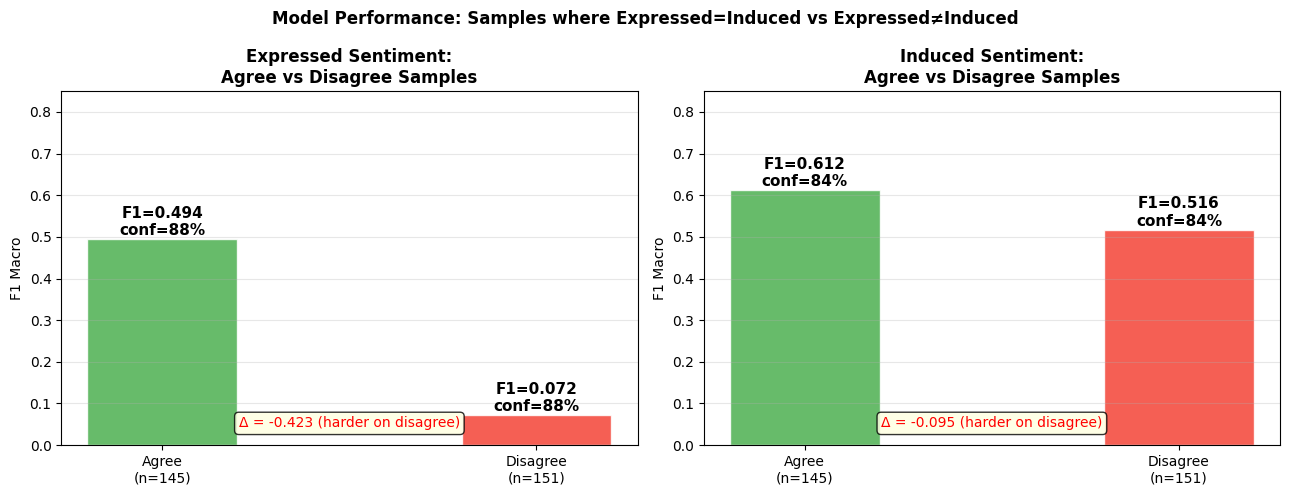

Saved: agree_vs_disagree_performance.png ✓


In [28]:
# ============================================================
# ΚΕΛΙ — AGREE vs DISAGREE COMPARISON CHART (#5)
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
for ax, task in zip(axes, ["expressed", "induced"]):
    agree_f1    = r_agree[task]["f1_macro"]
    disagree_f1 = r_disagree[task]["f1_macro"]
    agree_conf  = r_agree[task]["mean_conf"]
    disagree_conf = r_disagree[task]["mean_conf"]
    agree_n     = r_agree[task]["n_samples"]
    disagree_n  = r_disagree[task]["n_samples"]
 
    categories = [f"Agree\n(n={agree_n})", f"Disagree\n(n={disagree_n})"]
    f1s        = [agree_f1, disagree_f1]
    confs      = [agree_conf, disagree_conf]
    colors     = ["#4CAF50", "#F44336"]
 
    bars = ax.bar(categories, f1s, color=colors, edgecolor="white",
                  width=0.4, alpha=0.85)
    for bar, val, conf in zip(bars, f1s, confs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"F1={val:.3f}\nconf={conf:.0f}%",
                ha="center", fontsize=11, fontweight="bold")
 
    diff = disagree_f1 - agree_f1
    ax.set_ylim(0, 0.85)
    ax.set_ylabel("F1 Macro")
    ax.set_title(
        f"{task.capitalize()} Sentiment:\nAgree vs Disagree Samples",
        fontsize=12, fontweight="bold"
    )
    ax.grid(axis="y", alpha=0.3)
 
    ax.text(0.5, 0.05,
            f"Δ = {diff:+.3f} ({'harder' if diff < 0 else 'easier'} on disagree)",
            transform=ax.transAxes, ha="center", fontsize=10,
            color="red" if diff < 0 else "green",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
 
plt.suptitle("Model Performance: Samples where Expressed=Induced vs Expressed≠Induced",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("agree_vs_disagree_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: agree_vs_disagree_performance.png ✓")

In [29]:
# ============================================================
# ΚΕΛΙ — ΤΕΛΙΚΗ ΣΥΝΟΨΗ ΟΛΩΝ ΤΩΝ ΝΕΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

print("\n" + "="*70)
print("ΣΥΝΟΨΗ ΝΕΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ")
print("="*70)

# #1 Sonnet vs Haiku
# Haiku: παλιά αποτελέσματα από multimodal_unified_v2_media
print("\n--- #1 Sonnet vs Haiku ---")
haiku_f1 = {"expressed": 0.3366, "induced": 0.5935}
for task in ["expressed", "induced"]:
    s = [r for r in conf_results if r["task"] == task and "sonnet" in r["experiment"]][0]
    print(f"{task:10s}: Haiku={haiku_f1[task]:.4f} | Sonnet={s['f1_macro']:.4f} | Δ={s['f1_macro']-haiku_f1[task]:+.4f}")

# #2 Confidence info για Sonnet
print("\n--- #2 Sonnet Confidence ---")
for task in ["expressed", "induced"]:
    s = [r for r in conf_results if r["task"] == task and "sonnet" in r["experiment"]][0]
    print(f"{task:10s}: mean_conf={s['mean_conf']}%")

# #3 Text-only vs Multimodal
print("\n--- #3 Text-only vs Multimodal ---")
multi_df  = pd.read_csv("multimodal_results.csv")
textonly_df = pd.read_csv("textonly_results.csv")
v2_media_res = multi_df[multi_df["experiment"] == "multimodal_unified_v2_media"]
for task in ["expressed", "induced"]:
    mm = v2_media_res[v2_media_res["task"] == task].iloc[0]
    to = textonly_df[textonly_df["task"] == task].iloc[0]
    print(f"{task:10s}: Text-only={to['f1_macro']:.4f} | Multimodal={mm['f1_macro']:.4f} | Δ={mm['f1_macro']-to['f1_macro']:+.4f}")

# #5 Agree vs Disagree
print("\n--- #5 Agree vs Disagree ---")
for task in ["expressed", "induced"]:
    a = r_agree[task]
    d = r_disagree[task]
    print(f"{task:10s}: Agree={a['f1_macro']:.4f} (conf={a['mean_conf']}%) | "
          f"Disagree={d['f1_macro']:.4f} (conf={d['mean_conf']}%)")

print("\nFiles που δημιουργήθηκαν:")
for f in ["conf_results.csv", "textonly_results.csv",
          "confidence_threshold_analysis.png",
          "textonly_vs_multimodal.png",
          "agree_vs_disagree_performance.png"]:
    print(f"  {f}")


ΣΥΝΟΨΗ ΝΕΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ

--- #1 Sonnet vs Haiku ---
expressed : Haiku=0.3366 | Sonnet=0.3455 | Δ=+0.0089
induced   : Haiku=0.5935 | Sonnet=0.5620 | Δ=-0.0315

--- #2 Sonnet Confidence ---
expressed : mean_conf=88.6%
induced   : mean_conf=82.9%

--- #3 Text-only vs Multimodal ---
expressed : Text-only=0.3113 | Multimodal=0.3366 | Δ=+0.0253
induced   : Text-only=0.5054 | Multimodal=0.5935 | Δ=+0.0881

--- #5 Agree vs Disagree ---
expressed : Agree=0.4944 (conf=87.5%) | Disagree=0.0718 (conf=88.1%)
induced   : Agree=0.6118 (conf=84.5%) | Disagree=0.5165 (conf=84.3%)

Files που δημιουργήθηκαν:
  conf_results.csv
  textonly_results.csv
  confidence_threshold_analysis.png
  textonly_vs_multimodal.png
  agree_vs_disagree_performance.png


In [30]:
# ============================================================
# MULTIMODAL V3 — NEUTRAL IMPROVEMENT
#
# Αλλαγές από v2:
#   1. Αυστηρότερος ορισμός Neutral με explicit boundaries
#   2. Anti-bias instruction (no defaulting to Positive)
#   3. 3 Neutral few-shot examples αντί για 1
#      — ειδικά το pattern Neutral/Positive (το πιο συχνό λάθος)
#
# ΠΡΟΑΠΑΙΤΟΥΜΕΝΑ: κελιά 1-6 του v2 κώδικα φορτωμένα
# ============================================================
 
 
# ============================================================
# ΚΕΛΙ 1 — NEUTRAL-AWARE DEFINITIONS
# ============================================================
 
DEFS_MEDIA_V3 = {
    "positive": "The content is likely to attract engagement, shares, and positive reactions from a media audience. Clear positive emotional language, enthusiasm, celebration, or inspiring content.",
    "neutral":  "Purely informational or factual content with NO emotional language. No exclamation marks used emotionally, no loaded words, no promotional tone. Announcements, news reports, schedules, statistics. If there is ANY positive tone or warmth, it is NOT neutral — classify as Positive.",
    "negative": "The content is likely to provoke outrage, sadness, fear, or controversy in a media audience. Crisis news, accidents, criticism, conflict."
}
 
# Standard με neutral improvement
DEFS_STANDARD_V3 = {
    "positive": "The content expresses happiness, enthusiasm, praise, excitement, or other clearly positive emotions. Exclamation marks, celebratory language, strong approval.",
    "neutral":  "Purely factual or informational content with NO emotional charge whatsoever. The author states facts without any positive or negative coloring. Simple announcements, neutral descriptions, objective reporting. Do NOT classify as Neutral if there is even mild positivity — use Positive instead. Neutral is stricter than it seems.",
    "negative": "The content expresses sadness, anger, fear, frustration, criticism, or other clearly negative emotions."
}
 
print("V3 Definitions loaded ✓")
print("\nKey change in Neutral definition:")
print(DEFS_MEDIA_V3["neutral"])

V3 Definitions loaded ✓

Key change in Neutral definition:
Purely informational or factual content with NO emotional language. No exclamation marks used emotionally, no loaded words, no promotional tone. Announcements, news reports, schedules, statistics. If there is ANY positive tone or warmth, it is NOT neutral — classify as Positive.


In [31]:
# ============================================================
# ΚΕΛΙ 2 — NEUTRAL-AWARE FEW-SHOT EXAMPLES (v3)
#
# Βασική αλλαγή: 3 Neutral examples αντί για 1
# Ειδική έμφαση στο pattern Neutral/Positive
# (expressed=Neutral αλλά induced=Positive)
# ============================================================
 
FEW_SHOTS_V3 = [
    # --- AGREE cases (3) ---
    {
        "text": "Συγχαρητήρια στην ομάδα μας για την εκπληκτική νίκη! Υπέροχο αποτέλεσμα!",
        "image_desc": "Photo of celebrating athletes holding a trophy, crowd cheering",
        "expressed": "Positive",
        "induced": "Positive",
        "reasoning": "Author uses exclamation marks and celebratory words → expressed=Positive. Image reinforces celebration → induced=Positive."
    },
    {
        "text": "Σοβαρό τροχαίο ατύχημα στην Αθηνών-Λαμίας. Τρεις νεκροί και πέντε τραυματίες.",
        "image_desc": "Photo of damaged vehicles and emergency services at accident scene",
        "expressed": "Negative",
        "induced": "Negative",
        "reasoning": "Author reports tragedy → expressed=Negative. Image shows severity → induced=Negative."
    },
 
    # --- NEUTRAL examples (3 — the key improvement) ---
    {
        "text": "Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέντρο της Αθήνας.",
        "image_desc": "Photo of a clean storefront with opening hours sign",
        "expressed": "Neutral",
        "induced": "Neutral",
        "reasoning": "Author states a fact (opening time/location) with zero emotional language, no exclamation, no enthusiasm → expressed=Neutral. Image is informational only → induced=Neutral. NOTE: Even though it's a store opening (potentially good news), the TONE is purely factual."
    },
    {
        "text": "Η εκδήλωση πραγματοποιείται την Κυριακή 15 Δεκεμβρίου στις 19:00 στο Μέγαρο Μουσικής.",
        "image_desc": "Photo of a concert hall exterior at night",
        "expressed": "Neutral",
        "induced": "Positive",
        "reasoning": "Author simply announces an event — no emotional words, no enthusiasm, purely informational → expressed=Neutral. However, audience reading about a concert event at a prestigious venue would feel anticipation and interest → induced=Positive. IMPORTANT: expressed ≠ induced here. The author's TONE is neutral even if the content is pleasant."
    },
    {
        "text": "Νέα έρευνα δείχνει ότι η μεσογειακή διατροφή μειώνει τον κίνδυνο καρδιαγγειακών νοσημάτων κατά 30%.",
        "image_desc": "Photo of colorful vegetables and olive oil on a table",
        "expressed": "Neutral",
        "induced": "Positive",
        "reasoning": "Author reports a scientific finding objectively, no personal emotion → expressed=Neutral. The finding is good news for health, image is appealing → audience feels reassured and positive → induced=Positive. Again: expressed=Neutral, induced=Positive — these are different."
    },
 
    # --- DISAGREE case (expressed=Positive, induced=Neutral) ---
    {
        "text": "Η επιχείρησή σου αξίζει την καλύτερη προστασία. Ανακάλυψε τα νέα μας προγράμματα ασφάλισης.",
        "image_desc": "Professional photo of a smiling business owner at their shop",
        "expressed": "Positive",
        "induced": "Neutral",
        "reasoning": "Author promotes with confident, warm language → expressed=Positive. But audience receives this as routine advertising information without strong feeling → induced=Neutral. NOTE: expressed ≠ induced."
    },
]
 
print(f"V3 Few-shot examples: {len(FEW_SHOTS_V3)} ✓")
print("\nNeutral examples coverage:")
neutral_exs = [ex for ex in FEW_SHOTS_V3 if ex["expressed"] == "Neutral" or ex["induced"] == "Neutral"]
for ex in neutral_exs:
    print(f"  expressed={ex['expressed']:8s} induced={ex['induced']:8s} | {ex['text'][:60]}...")

V3 Few-shot examples: 6 ✓

Neutral examples coverage:
  expressed=Neutral  induced=Neutral  | Το νέο κατάστημά μας ανοίγει την Παρασκευή στις 10:00 στο κέ...
  expressed=Neutral  induced=Positive | Η εκδήλωση πραγματοποιείται την Κυριακή 15 Δεκεμβρίου στις 1...
  expressed=Neutral  induced=Positive | Νέα έρευνα δείχνει ότι η μεσογειακή διατροφή μειώνει τον κίν...
  expressed=Positive induced=Neutral  | Η επιχείρησή σου αξίζει την καλύτερη προστασία. Ανακάλυψε τα...


In [32]:
# ============================================================
# ΚΕΛΙ 3 — V3 PROMPT BUILDER
#
# Αλλαγές από v2:
#   - Anti-bias warning για Neutral
#   - Explicit decision rule: "when in doubt between Positive and Neutral → Neutral"
#   - Extra CoT step για Neutral check
# ============================================================
 
def build_unified_prompt_v3(text, defs, few_shots):
    examples_text = ""
    for i, ex in enumerate(few_shots, 1):
        examples_text += f"""
Example {i}:
Image shows: {ex['image_desc']}
Text: "{ex['text']}"
Step 1 - Image content: {ex['image_desc']}
Step 2 - Author's words: {ex['text'][:80]}
Step 3 - Image relation to text: {"Reinforces" if ex["expressed"] == ex["induced"] else "Adds different context"}
Step 4 - Expressed: {ex['expressed']}
Step 5 - Induced: {ex['induced']}
Reasoning: {ex['reasoning']}
{{"expressed": "{ex['expressed']}", "induced": "{ex['induced']}"}}
"""
 
    prompt = f"""You are an expert sentiment analyst specializing in social media content.
 
TASK: Given a social media post (image + text), classify TWO sentiments:
1. EXPRESSED sentiment = what emotion the AUTHOR explicitly shows in their WRITING STYLE
2. INDUCED sentiment = what emotion the AUDIENCE/READER is likely to feel
 
CRITICAL RULES:
- These two can be DIFFERENT (e.g. author writes neutrally but content makes audience feel positive)
- NEUTRAL is STRICT: only use it when there is absolutely NO emotional language. Purely factual tone, no exclamation marks used emotionally, no warm or enthusiastic words.
- Do NOT default to Positive. Many informational posts are Neutral even if the topic is pleasant.
- When in doubt between Positive and Neutral for EXPRESSED: ask "Is the author showing emotion or just stating facts?" — if just facts → Neutral.
- When in doubt between Positive and Neutral for INDUCED: ask "Would an average reader feel something or just be informed?" — if just informed → Neutral.
 
Sentiment Definitions:
- Positive: {defs['positive']}
- Neutral:  {defs['neutral']}
- Negative: {defs['negative']}
 
Examples:
{examples_text}
 
Now classify THIS post using BOTH the image AND the text:
Text: "{text}"
 
Think step by step:
Step 1 - What does the image show:
Step 2 - What is the author saying (tone and content):
Step 3 - Does the author use emotional language or just state facts? (key for expressed)
Step 4 - Does the image reinforce, contradict, or add context to the text:
Step 5 - Expressed sentiment (author's emotional tone):
Step 6 - Would the audience feel something or just be informed? (key for induced)
Step 7 - Induced sentiment (audience reaction):
 
Return ONLY this JSON at the end:
{{"expressed": "Positive/Neutral/Negative", "induced": "Positive/Neutral/Negative"}}"""
 
    return prompt
 
 
# Quick test
sample_prompt = build_unified_prompt_v3("Δοκιμή...", DEFS_MEDIA_V3, FEW_SHOTS_V3)
print(f"V3 Prompt length: {len(sample_prompt)} chars ✓")

V3 Prompt length: 6742 chars ✓


In [33]:
# ============================================================
# ΚΕΛΙ 4 — CLASSIFY FUNCTION V3
# ============================================================
 
def classify_multimodal_v3(text, image_path, defs, few_shots,
                            model="claude-haiku-4-5-20251001"):
    img_b64, media_type = load_image_base64(image_path)
    if img_b64 is None:
        return {"expressed": "Error", "induced": "Error"}
 
    prompt = build_unified_prompt_v3(text, defs, few_shots)
 
    try:
        response = client.messages.create(
            model=model,
            max_tokens=600,
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_b64
                        }
                    },
                    {"type": "text", "text": prompt}
                ]
            }]
        )
        raw      = response.content[0].text
        json_str = raw[raw.rfind("{"):raw.rfind("}")+1]
        parsed   = json.loads(json_str)
 
        valid     = {"Positive", "Neutral", "Negative"}
        expressed = parsed.get("expressed", "Error").capitalize()
        induced   = parsed.get("induced",   "Error").capitalize()
        if expressed not in valid: expressed = "Error"
        if induced   not in valid: induced   = "Error"
 
        return {"expressed": expressed, "induced": induced}
 
    except Exception as e:
        print("Error:", e)
        return {"expressed": "Error", "induced": "Error"}
 
 
print("V3 classify function ready ✓")

V3 classify function ready ✓


In [34]:
# ============================================================
# ΚΕΛΙ 5 — TEST ΣΕ 5 SAMPLES (ειδικά disagree samples)
# ============================================================
 
print("Test v3 σε 5 disagree samples...\n")
 
# Παίρνουμε disagree samples για test
test_disagree_sample = test_df[
    (test_df["voted_expressed"].str.lower() != test_df["voted_induced"].str.lower()) &
    (test_df["fname"].notna())
].head(5).copy()
 
for _, row in test_disagree_sample.iterrows():
    img_path = find_image_path(row["fname"], IMAGE_DIR)
    if img_path is None:
        continue
 
    # V2 prediction
    result_v2 = classify_multimodal_v2(
        row["text_norm_clean"], img_path, DEFS_MEDIA, FEW_SHOTS_V2
    )
    # V3 prediction
    result_v3 = classify_multimodal_v3(
        row["text_norm_clean"], img_path, DEFS_MEDIA_V3, FEW_SHOTS_V3
    )
 
    true_exp = row["voted_expressed"]
    true_ind = row["voted_induced"]
 
    print(f"Text: {row['text_norm_clean'][:55]}...")
    print(f"  True:  exp={true_exp:8s} ind={true_ind}")
    print(f"  V2:    exp={result_v2['expressed']:8s} ind={result_v2['induced']}")
    print(f"  V3:    exp={result_v3['expressed']:8s} ind={result_v3['induced']}")
    print()
    time.sleep(0.5)

Test v3 σε 5 disagree samples...

Error: Expecting value: line 1 column 1 (char 0)
Text: Премиера на “Хадерал – последното пътуване на Константи...
  True:  exp=Neutral  ind=Negative
  V2:    exp=Positive ind=Positive
  V3:    exp=Error    ind=Error

Text: A small island, lost in the middle of nowhere. Time doe...
  True:  exp=Neutral  ind=Positive
  V2:    exp=Positive ind=Positive
  V3:    exp=Positive ind=Positive

Text: Backstage από τη Ράνια Τζίμα και το Κεντρικό Δελτίο του...
  True:  exp=Neutral  ind=Positive
  V2:    exp=Positive ind=Positive
  V3:    exp=Positive ind=Positive

Text: Πρώτη μέρα σχολείο: Νέες τσάντες. Νέα αρχή. Ίδια επική ...
  True:  exp=Neutral  ind=Positive
  V2:    exp=Positive ind=Positive
  V3:    exp=Positive ind=Positive



In [35]:
 
# ============================================================
# ΚΕΛΙ 6 — FULL EXPERIMENT V3 (media defs)
# ============================================================
 
def run_multimodal_v3_experiment(defs, exp_name, few_shots,
                                  image_dir="matched_images/matched_images",
                                  model="claude-haiku-4-5-20251001"):
    print("\n" + "="*60)
    print(f"Experiment: {exp_name}")
    print("="*60)
 
    subset = test_df[test_df["fname"].notna()].copy()
    subset["image_path"] = subset["fname"].apply(
        lambda x: find_image_path(x, image_dir)
    )
    subset = subset[subset["image_path"].notna()].copy()
    print(f"Samples με εικόνα: {len(subset)}")
 
    expressed_preds, induced_preds = [], []
 
    for _, row in tqdm(subset.iterrows(), total=len(subset)):
        result = classify_multimodal_v3(
            row["text_norm_clean"], row["image_path"], defs, few_shots, model=model
        )
        expressed_preds.append(result["expressed"])
        induced_preds.append(result["induced"])
 
    subset["pred_expressed"] = expressed_preds
    subset["pred_induced"]   = induced_preds
 
    results = {}
    for task, pred_col, true_col in [
        ("expressed", "pred_expressed", "voted_expressed"),
        ("induced",   "pred_induced",   "voted_induced")
    ]:
        mask   = subset[pred_col] != "Error"
        y_true = subset.loc[mask, true_col].str.capitalize()
        y_pred = subset.loc[mask, pred_col]
 
        report = classification_report(
            y_true, y_pred,
            labels=["Negative", "Neutral", "Positive"],
            output_dict=True, zero_division=0
        )
 
        results[task] = {
            "experiment":  exp_name,
            "task":        task,
            "n_samples":   len(subset),
            "n_errors":    int((subset[pred_col] == "Error").sum()),
            "accuracy":    round(report["accuracy"], 4),
            "f1_macro":    round(report["macro avg"]["f1-score"], 4),
            "f1_negative": round(report["Negative"]["f1-score"], 4),
            "f1_neutral":  round(report["Neutral"]["f1-score"], 4),
            "f1_positive": round(report["Positive"]["f1-score"], 4),
        }
 
        print(f"\n{task.upper()}:")
        print(f"  Errors:   {results[task]['n_errors']}")
        print(f"  Acc={results[task]['accuracy']} | F1_macro={results[task]['f1_macro']}")
        print(f"  Neg={results[task]['f1_negative']} | Neu={results[task]['f1_neutral']} | Pos={results[task]['f1_positive']}")
 
    return results, subset
 
 
# Τρέξε v3 με media defs (~25 λεπτά)
r_v3, subset_v3 = run_multimodal_v3_experiment(
    defs      = DEFS_MEDIA_V3,
    exp_name  = "multimodal_v3_neutral_media",
    few_shots = FEW_SHOTS_V3
)
 
# Save
v3_rows = []
for task, res in r_v3.items():
    v3_rows.append({
        "method":      "Multimodal_Claude_v3",
        "model":       "claude-haiku-4-5-20251001",
        "experiment":  res["experiment"],
        "task":        res["task"],
        "n_samples":   res["n_samples"],
        "n_errors":    res["n_errors"],
        "accuracy":    res["accuracy"],
        "f1_macro":    res["f1_macro"],
        "f1_negative": res["f1_negative"],
        "f1_neutral":  res["f1_neutral"],
        "f1_positive": res["f1_positive"],
    })
 
multi_df = pd.read_csv("multimodal_results.csv")
multi_df = pd.concat([multi_df, pd.DataFrame(v3_rows)], ignore_index=True)
multi_df.to_csv("multimodal_results.csv", index=False)
print("\nSaved to multimodal_results.csv ✓")


Experiment: multimodal_v3_neutral_media
Samples με εικόνα: 296


  1%|          | 3/296 [00:17<28:28,  5.83s/it]

Error: Expecting value: line 1 column 1 (char 0)


  1%|▏         | 4/296 [00:24<31:06,  6.39s/it]

Error: Expecting value: line 1 column 1 (char 0)


...

Error: Expecting value: line 1 column 1 (char 0)


 11%|█         | 32/296 [03:18<26:09,  5.94s/it]

Error: Expecting value: line 1 column 1 (char 0)


 12%|█▏        | 36/296 [03:51<27:52,  6.43s/it]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# ΚΕΛΙ 7 — ΣΥΓΚΡΙΣΗ V2 vs V3 (focus on Neutral)
# ============================================================
 
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
 
v2_res = multi_df[multi_df["experiment"] == "multimodal_unified_v2_media"]
v3_res = multi_df[multi_df["experiment"] == "multimodal_v3_neutral_media"]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, task in zip(axes, ["expressed", "induced"]):
    v2 = v2_res[v2_res["task"] == task].iloc[0]
    v3 = v3_res[v3_res["task"] == task].iloc[0]
 
    classes   = ["Negative", "Neutral", "Positive", "F1_macro"]
    v2_scores = [v2["f1_negative"], v2["f1_neutral"], v2["f1_positive"], v2["f1_macro"]]
    v3_scores = [v3["f1_negative"], v3["f1_neutral"], v3["f1_positive"], v3["f1_macro"]]
 
    x     = range(len(classes))
    width = 0.35
 
    bars_v2 = ax.bar([i - width/2 for i in x], v2_scores,
                     width, label="V2 (baseline)", color="#9C27B0", alpha=0.8, edgecolor="white")
    bars_v3 = ax.bar([i + width/2 for i in x], v3_scores,
                     width, label="V3 (neutral fix)", color="#4CAF50", alpha=0.8, edgecolor="white")
 
    # Value labels
    for bar in bars_v2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    for bar in bars_v3:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
 
    # Highlight Neutral column
    ax.axvspan(0.5, 1.5, alpha=0.08, color="orange", label="Neutral class (target)")
 
    ax.set_xticks(list(x))
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 0.85)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"{task.capitalize()} Sentiment: V2 vs V3", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
 
plt.suptitle("V2 vs V3: Impact of Neutral-Aware Prompt Engineering",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("v2_vs_v3_neutral.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: v2_vs_v3_neutral.png ✓")
 
# Τελική σύγκριση
print("\n=== V2 vs V3 ΣΥΓΚΡΙΣΗ ===")
for task in ["expressed", "induced"]:
    v2 = v2_res[v2_res["task"] == task].iloc[0]
    v3 = v3_res[v3_res["task"] == task].iloc[0]
    print(f"\n{task.upper()}:")
    print(f"  F1_macro:  V2={v2['f1_macro']:.4f} → V3={v3['f1_macro']:.4f} ({v3['f1_macro']-v2['f1_macro']:+.4f})")
    print(f"  F1_neutral: V2={v2['f1_neutral']:.4f} → V3={v3['f1_neutral']:.4f} ({v3['f1_neutral']-v2['f1_neutral']:+.4f})")
    print(f"  F1_negative:V2={v2['f1_negative']:.4f} → V3={v3['f1_negative']:.4f}")
    print(f"  F1_positive:V2={v2['f1_positive']:.4f} → V3={v3['f1_positive']:.4f}")
 